<a href="https://colab.research.google.com/github/opaiot/ia-otimizacao-iot-industrias-negocios-public/blob/feature%2Fsync-colab/M1/colab/M1_Aulas_16_26_Aplica%C3%A7%C3%A3o_Pr%C3%A1tica_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Contexto do problema industrial

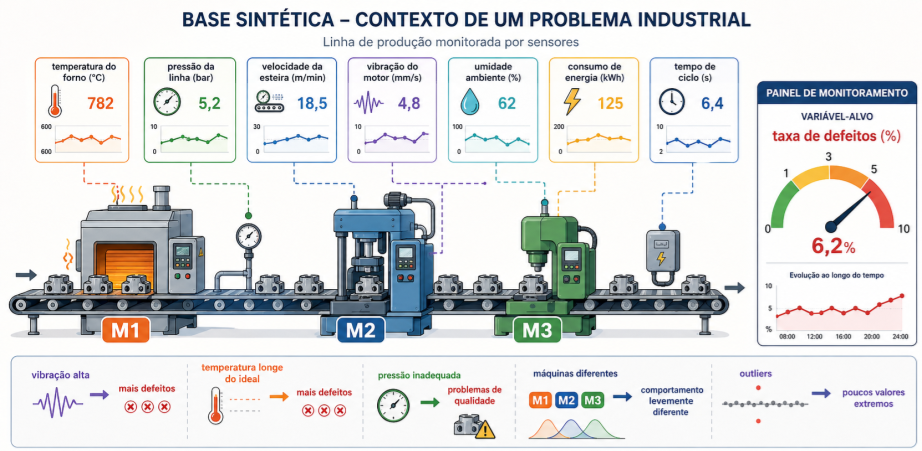


A equipe de engenharia quer usar esses dados para duas tarefas:

### Problema de regressão

Prever uma variável contínua:

| Alvo | Significado |
|---|---|
| `taxa_defeitos_pct` | Percentual de peças defeituosas no período |

### Problema de classificação

Identificar se o processo está em condição crítica:

| Alvo | Significado |
|---|---|
| `processo_critico` | 1 para processo crítico; 0 para processo normal |

### Principais atributos da base

| Atributo | Tipo | Descrição |
|---|---|---|
| `turno` | Categórico | Manhã, tarde ou noite |
| `maquina` | Categórico | Máquina usada |
| `fornecedor_lote` | Categórico | Fornecedor do lote |
| `familia_produto` | Categórico | Família do produto |
| `nivel_manutencao` | Categórico | Condição de manutenção |
| `temperatura_forno_c` | Numérico | Temperatura do forno |
| `desvio_temperatura_c` | Numérico | Distância em relação à temperatura ideal de 180 °C |
| `pressao_linha_bar` | Numérico | Pressão da linha |
| `velocidade_esteira_m_min` | Numérico | Velocidade da esteira |
| `vibracao_motor_mm_s` | Numérico | Vibração do motor |
| `umidade_ambiente_pct` | Numérico | Umidade ambiente |
| `consumo_energia_kwh` | Numérico | Consumo de energia |
| `tempo_ciclo_s` | Numérico | Tempo médio de ciclo |
| `dias_desde_manutencao` | Numérico | Dias desde a última manutenção |
| `indice_desgaste` | Numérico | Indicador sintético de desgaste |
| `qtd_produzida` | Numérico | Quantidade produzida |

## 2. Modelos e Métricas

| Parte | Tipo de problema | Modelos |
|---|---|---|
| 1 | Regressão | Regressão Linear |
| 2 | Regressão | Ridge e Lasso |
| 3 | Classificação | Regressão Logística |
| 4 | Regressão e classificação | Árvore de Decisão |
| 5 | Regressão e classificação | Floresta Aleatória |
| 6 | Regressão e classificação | XGBoost |
| 7 | Organização do fluxo | `Pipeline` e `ColumnTransformer` |

Métricas:

| Tipo de problema | Métricas |
|---|---|
| Regressão | MAE, RMSE e R² |
| Classificação | Acurácia, precisão, recall, F1-score, curva ROC e AUC |

## 3. Bibliotecas

A próxima célula importa as bibliotecas necessárias.

Recursos importantes:

- `pandas` e `numpy`: criação e manipulação da base;
- `matplotlib` e `seaborn`: gráficos;
- `train_test_split`: divisão em treino e teste;
- `StandardScaler`: padronização dos atributos;
- `LinearRegression`, `Ridge`, `Lasso`, `LogisticRegression`: modelos lineares;
- `DecisionTree`, `RandomForest` e `XGBoost`: modelos baseados em árvores;
- `metrics`: métricas de regressão e classificação.

A célula também tenta importar o `xgboost`. Se ele não estiver instalado, o notebook instala automaticamente.

In [ ]:
# ------------------------------------------------------------
# 1) Importação das bibliotecas
# ------------------------------------------------------------

import sys
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

try:
    from xgboost import XGBRegressor, XGBClassifier
    print("xgboost importado com sucesso.")
except ImportError:
    print("xgboost não encontrado. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBRegressor, XGBClassifier
    print("xgboost instalado e importado com sucesso.")

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")

xgboost importado com sucesso.
Bibliotecas carregadas com sucesso!


## 4. Geração da base sintética e salvamento em CSV

Vamos gerar a base sintética e salvá-la em um arquivo CSV para ser usada imediatamente com `pd.read_csv()`.

Principais recursos usados:

- `np.random.default_rng(42)`: cria um gerador aleatório reprodutível;
- `rng.normal(...)`: gera variáveis numéricas;
- `rng.choice(...)`: gera variáveis categóricas;
- `pd.cut(...)`: cria categorias a partir de faixas numéricas;
- `pd.DataFrame(...)`: cria a tabela;
- `df.to_csv(..., index=False)`: salva o CSV sem criar uma coluna extra de índice.

A base será salva como:

```python
dados_linha_producao_modelos.csv
```

In [ ]:
# ------------------------------------------------------------
# 2) Geração da base sintética industrial
# ------------------------------------------------------------

rng = np.random.default_rng(42)
n = 850

id_registro = np.arange(1, n + 1)
data_coleta = pd.date_range(start="2026-01-01 00:00:00", periods=n, freq="h")

turno = rng.choice(["Manhã", "Tarde", "Noite"], size=n, p=[0.38, 0.34, 0.28])
maquina = rng.choice(["M1", "M2", "M3", "M4"], size=n, p=[0.32, 0.28, 0.25, 0.15])
fornecedor_lote = rng.choice(["Forn_A", "Forn_B", "Forn_C", "Forn_D", "Forn_E"], size=n)
familia_produto = rng.choice(["Pote", "Ampola", "Frasco"], size=n, p=[0.42, 0.33, 0.25])

efeito_maquina_temp = {"M1": -1.0, "M2": 0.3, "M3": 1.2, "M4": 2.0}
efeito_maquina_vib = {"M1": -0.2, "M2": 0.1, "M3": 0.4, "M4": 0.8}
efeito_fornecedor = {"Forn_A": -0.25, "Forn_B": 0.05, "Forn_C": 0.20, "Forn_D": 0.35, "Forn_E": -0.10}
efeito_produto = {"Pote": 0.20, "Ampola": -0.10, "Frasco": 0.05}

ajuste_temp = np.array([efeito_maquina_temp[m] for m in maquina])
ajuste_vib = np.array([efeito_maquina_vib[m] for m in maquina])
ajuste_fornecedor = np.array([efeito_fornecedor[f] for f in fornecedor_lote])
ajuste_produto = np.array([efeito_produto[p] for p in familia_produto])

temperatura_forno_c = rng.normal(loc=180, scale=5.5, size=n) + ajuste_temp
pressao_linha_bar = rng.normal(loc=6.1, scale=0.45, size=n)
velocidade_esteira_m_min = rng.normal(loc=32, scale=3.2, size=n)
vibracao_motor_mm_s = rng.normal(loc=3.0, scale=0.65, size=n) + ajuste_vib
umidade_ambiente_pct = rng.normal(loc=55, scale=8.5, size=n)
tempo_ciclo_s = rng.normal(loc=42, scale=4.0, size=n)
dias_desde_manutencao = rng.integers(0, 90, size=n)

pressao_linha_bar = np.clip(pressao_linha_bar, 4.6, 7.6)
velocidade_esteira_m_min = np.clip(velocidade_esteira_m_min, 20, 45)
vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 8.5)
umidade_ambiente_pct = np.clip(umidade_ambiente_pct, 25, 90)
tempo_ciclo_s = np.clip(tempo_ciclo_s, 30, 62)

desvio_temperatura_c = np.abs(temperatura_forno_c - 180)

indice_desgaste = (
    1.2
    + 0.030 * dias_desde_manutencao
    + 0.55 * vibracao_motor_mm_s
    + rng.normal(0, 0.45, size=n)
)

indice_desgaste = np.clip(indice_desgaste, 0.5, 10)

nivel_manutencao = pd.cut(
    indice_desgaste,
    bins=[-np.inf, 3.2, 5.2, np.inf],
    labels=["Baixa atenção", "Atenção moderada", "Alta atenção"]
).astype(str)

consumo_energia_kwh = (
    48
    + 0.20 * temperatura_forno_c
    + 0.52 * velocidade_esteira_m_min
    + 0.35 * tempo_ciclo_s
    + 1.8 * indice_desgaste
    + rng.normal(0, 4.5, size=n)
)

qtd_produzida = (
    900
    + 18 * velocidade_esteira_m_min
    - 5.5 * tempo_ciclo_s
    + rng.normal(0, 45, size=n)
)

qtd_produzida = np.clip(qtd_produzida, 500, 1600)

taxa_defeitos_pct = (
    1.6
    + 0.72 * vibracao_motor_mm_s
    + 0.25 * desvio_temperatura_c
    + 0.33 * np.maximum(0, 5.9 - pressao_linha_bar)
    + 0.16 * indice_desgaste
    + 0.018 * umidade_ambiente_pct
    + ajuste_fornecedor
    + ajuste_produto
    + rng.normal(0, 1.05, size=n)
)

indices_eventos = rng.choice(np.arange(n), size=24, replace=False)
vibracao_motor_mm_s[indices_eventos] += rng.normal(2.0, 0.5, size=len(indices_eventos))
indice_desgaste[indices_eventos] += rng.normal(1.4, 0.3, size=len(indices_eventos))
taxa_defeitos_pct[indices_eventos] += rng.normal(4.0, 1.0, size=len(indices_eventos))

vibracao_motor_mm_s = np.clip(vibracao_motor_mm_s, 1.0, 9.5)
indice_desgaste = np.clip(indice_desgaste, 0.5, 10)
taxa_defeitos_pct = np.clip(taxa_defeitos_pct, 0.2, 22)

limite_critico = np.quantile(taxa_defeitos_pct, 0.75)
processo_critico = (taxa_defeitos_pct >= limite_critico).astype(int)

classe_qualidade = pd.cut(
    taxa_defeitos_pct,
    bins=[-np.inf, np.quantile(taxa_defeitos_pct, 0.50), limite_critico, np.inf],
    labels=["Boa", "Atenção", "Crítica"]
).astype(str)

df = pd.DataFrame({
    "id_registro": id_registro,
    "data_coleta": data_coleta,
    "turno": turno,
    "maquina": maquina,
    "fornecedor_lote": fornecedor_lote,
    "familia_produto": familia_produto,
    "nivel_manutencao": nivel_manutencao,
    "temperatura_forno_c": temperatura_forno_c,
    "desvio_temperatura_c": desvio_temperatura_c,
    "pressao_linha_bar": pressao_linha_bar,
    "velocidade_esteira_m_min": velocidade_esteira_m_min,
    "vibracao_motor_mm_s": vibracao_motor_mm_s,
    "umidade_ambiente_pct": umidade_ambiente_pct,
    "consumo_energia_kwh": consumo_energia_kwh,
    "tempo_ciclo_s": tempo_ciclo_s,
    "dias_desde_manutencao": dias_desde_manutencao,
    "indice_desgaste": indice_desgaste,
    "qtd_produzida": qtd_produzida,
    "taxa_defeitos_pct": taxa_defeitos_pct,
    "processo_critico": processo_critico,
    "classe_qualidade": classe_qualidade
})

colunas_numericas = df.select_dtypes(include="number").columns
df[colunas_numericas] = df[colunas_numericas].round(3)

nome_arquivo = "dados_linha_producao_modelos.csv"
df.to_csv(nome_arquivo, index=False)

print(f"Arquivo salvo com sucesso: {nome_arquivo}")
print("Dimensões da base:", df.shape)
print(f"Limite usado para definir processo crítico: {limite_critico:.2f}% de defeitos")

display(df.head())

Arquivo salvo com sucesso: dados_linha_producao_modelos.csv
Dimensões da base: (850, 21)
Limite usado para definir processo crítico: 7.91% de defeitos


,id_registro,data_coleta,turno,maquina,fornecedor_lote,familia_produto,nivel_manutencao,temperatura_forno_c,desvio_temperatura_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,dias_desde_manutencao,indice_desgaste,qtd_produzida,taxa_defeitos_pct,processo_critico,classe_qualidade
0,1,2026-01-01 00:00:00,Noite,M1,Forn_E,Pote,Alta atenção,172.405,7.595,6.279,28.351,3.206,65.751,124.737,42.549,81,5.930,1212.309,9.615,1,Crítica
1,2,2026-01-01 01:00:00,Tarde,M1,Forn_E,Pote,Atenção moderada,181.991,1.991,5.296,30.617,3.385,42.701,118.764,36.995,27,3.847,1173.893,7.960,1,Crítica
2,3,2026-01-01 02:00:00,Noite,M4,Forn_A,Pote,Alta atenção,179.333,0.667,5.900,32.312,6.609,59.817,131.727,41.640,89,7.546,1192.260,11.832,1,Crítica
3,4,2026-01-01 03:00:00,Tarde,M4,Forn_E,Pote,Atenção moderada,192.384,12.384,6.442,38.371,3.695,65.383,128.266,42.885,33,4.243,1328.195,10.574,1,Crítica
4,5,2026-01-01 04:00:00,Manhã,M1,Forn_B,Pote,Atenção moderada,178.994,1.006,6.236,30.647,2.109,55.665,117.317,40.336,64,4.336,1260.540,5.371,0,Boa


### Interpretação da base gerada

A base contém registros sintéticos de operação. Cada linha representa um período de produção.

Foram criados dois alvos:

- `taxa_defeitos_pct`: alvo de regressão;
- `processo_critico`: alvo de classificação.

A coluna `classe_qualidade` é apenas explicativa. Como ela foi derivada da taxa de defeitos, não deve ser usada como atributo de entrada do modelo.

## 5. Leitura do CSV com `pd.read_csv()`

Agora vamos ler o CSV que acabou de ser salvo.

Principais recursos:

- `pd.read_csv(...)`: lê o arquivo;
- `.head()`: mostra as primeiras linhas;
- `.info()`: mostra tipos das colunas;
- `.value_counts()`: conta as classes.

In [ ]:
# ------------------------------------------------------------
# 3) Leitura da base
# ------------------------------------------------------------

dados = pd.read_csv("dados_linha_producao_modelos.csv")

print("Dimensões da base:")
print(dados.shape)

print("\nPrimeiras linhas:")
display(dados.head())

print("\nInformações gerais:")
dados.info()

print("\nDistribuição da variável processo_critico:")
display(dados["processo_critico"].value_counts().rename({0: "Normal", 1: "Crítico"}))

print("\nProporção das classes (%):")
display((dados["processo_critico"].value_counts(normalize=True) * 100).round(2).rename({0: "Normal", 1: "Crítico"}))

Dimensões da base:
(850, 21)

Primeiras linhas:


,id_registro,data_coleta,turno,maquina,fornecedor_lote,familia_produto,nivel_manutencao,temperatura_forno_c,desvio_temperatura_c,pressao_linha_bar,velocidade_esteira_m_min,vibracao_motor_mm_s,umidade_ambiente_pct,consumo_energia_kwh,tempo_ciclo_s,dias_desde_manutencao,indice_desgaste,qtd_produzida,taxa_defeitos_pct,processo_critico,classe_qualidade
0,1,2026-01-01 00:00:00,Noite,M1,Forn_E,Pote,Alta atenção,172.405,7.595,6.279,28.351,3.206,65.751,124.737,42.549,81,5.930,1212.309,9.615,1,Crítica
1,2,2026-01-01 01:00:00,Tarde,M1,Forn_E,Pote,Atenção moderada,181.991,1.991,5.296,30.617,3.385,42.701,118.764,36.995,27,3.847,1173.893,7.960,1,Crítica
2,3,2026-01-01 02:00:00,Noite,M4,Forn_A,Pote,Alta atenção,179.333,0.667,5.900,32.312,6.609,59.817,131.727,41.640,89,7.546,1192.260,11.832,1,Crítica
3,4,2026-01-01 03:00:00,Tarde,M4,Forn_E,Pote,Atenção moderada,192.384,12.384,6.442,38.371,3.695,65.383,128.266,42.885,33,4.243,1328.195,10.574,1,Crítica
4,5,2026-01-01 04:00:00,Manhã,M1,Forn_B,Pote,Atenção moderada,178.994,1.006,6.236,30.647,2.109,55.665,117.317,40.336,64,4.336,1260.540,5.371,0,Boa



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_registro               850 non-null    int64  
 1   data_coleta               850 non-null    object 
 2   turno                     850 non-null    object 
 3   maquina                   850 non-null    object 
 4   fornecedor_lote           850 non-null    object 
 5   familia_produto           850 non-null    object 
 6   nivel_manutencao          850 non-null    object 
 7   temperatura_forno_c       850 non-null    float64
 8   desvio_temperatura_c      850 non-null    float64
 9   pressao_linha_bar         850 non-null    float64
 10  velocidade_esteira_m_min  850 non-null    float64
 11  vibracao_motor_mm_s       850 non-null    float64
 12  umidade_ambiente_pct      850 non-null    float64
 13  consumo_energia_kwh       850 non-null    fl

,count
processo_critico,
Normal,637
Crítico,213



Proporção das classes (%):


,proportion
processo_critico,
Normal,74.94
Crítico,25.06


### Interpretação inicial

A classe crítica representa aproximadamente os 25% dos períodos com maior taxa de defeitos.

Essa definição é didática. Em um caso real, o limite crítico poderia vir de normas de qualidade, contratos, metas internas ou decisão da equipe de engenharia.

## 6. Visualização dos alvos

Vamos visualizar:

- a distribuição da taxa de defeitos;
- a quantidade de casos normais e críticos.

Isso ajuda a entender o problema antes de treinar modelos.

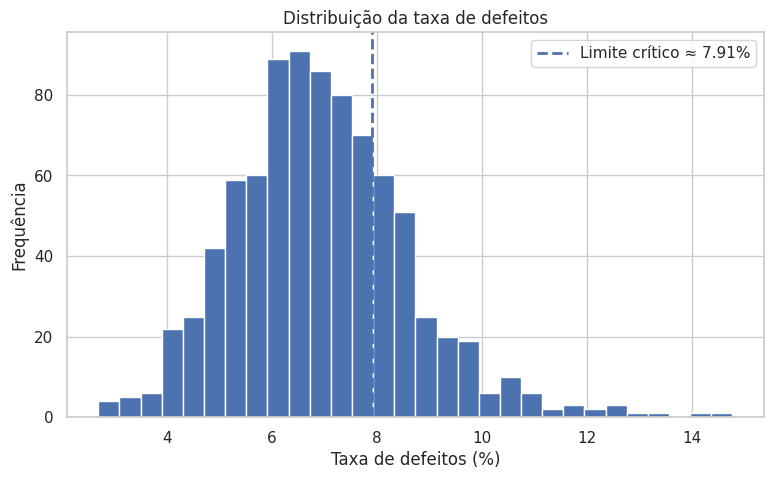

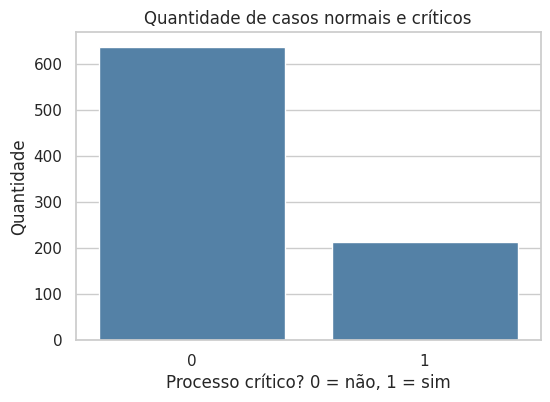

In [ ]:
# ------------------------------------------------------------
# 4) Visualização dos alvos
# ------------------------------------------------------------

limite_observado = dados.loc[dados["processo_critico"] == 1, "taxa_defeitos_pct"].min()

plt.figure(figsize=(9, 5))
plt.hist(dados["taxa_defeitos_pct"], bins=30)
plt.axvline(limite_observado, linestyle="--", linewidth=2, label=f"Limite crítico ≈ {limite_observado:.2f}%")
plt.title("Distribuição da taxa de defeitos")
plt.xlabel("Taxa de defeitos (%)")
plt.ylabel("Frequência")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(data=dados, x="processo_critico", color="steelblue")
plt.title("Quantidade de casos normais e críticos")
plt.xlabel("Processo crítico? 0 = não, 1 = sim")
plt.ylabel("Quantidade")
plt.show()

### Interpretação

O histograma mostra a distribuição da taxa de defeitos. A linha vertical marca o início da região crítica.

O gráfico de barras mostra o número de exemplos em cada classe. Como a classe crítica é menos frequente, métricas como precisão, recall e F1-score serão importantes.

## 7. Separação entre atributos e alvos

Vamos definir:

- `X`: atributos de entrada;
- `y_reg`: alvo de regressão;
- `y_clf`: alvo de classificação.

Também vamos remover colunas que não devem ser usadas como entrada:

- `id_registro`: identificador;
- `data_coleta`: nesta aula, não usaremos atributos temporais;
- `taxa_defeitos_pct`: alvo da regressão;
- `processo_critico`: alvo da classificação;
- `classe_qualidade`: derivada da taxa de defeitos, portanto geraria vazamento de informação.

Vazamento de informação ocorre quando o modelo usa, direta ou indiretamente, informação que não estaria disponível no momento real da previsão.

In [ ]:
# ------------------------------------------------------------
# 5) Definição de X e y
# ------------------------------------------------------------

colunas_remover = [
    "id_registro",
    "data_coleta",
    "taxa_defeitos_pct",
    "processo_critico",
    "classe_qualidade"
]

X = dados.drop(columns=colunas_remover)

y_reg = dados["taxa_defeitos_pct"]
y_clf = dados["processo_critico"]

#Guardando os tipos de atributo para uso futuro
atributos_numericos = list(X.select_dtypes(include="number").columns)
atributos_categoricos = list(X.select_dtypes(exclude="number").columns)

print("Atributos numéricos:")
print(atributos_numericos)

print("\nAtributos categóricos:")
print(atributos_categoricos)

print("\nDimensão de X:", X.shape)
print("Dimensão de y_reg:", y_reg.shape)
print("Dimensão de y_clf:", y_clf.shape)

Atributos numéricos:
['temperatura_forno_c', 'desvio_temperatura_c', 'pressao_linha_bar', 'velocidade_esteira_m_min', 'vibracao_motor_mm_s', 'umidade_ambiente_pct', 'consumo_energia_kwh', 'tempo_ciclo_s', 'dias_desde_manutencao', 'indice_desgaste', 'qtd_produzida']

Atributos categóricos:
['turno', 'maquina', 'fornecedor_lote', 'familia_produto', 'nivel_manutencao']

Dimensão de X: (850, 16)
Dimensão de y_reg: (850,)
Dimensão de y_clf: (850,)


### Interpretação

A mesma matriz `X` será usada para regressão e classificação.

A diferença está no alvo:

- em regressão, queremos prever um valor numérico;
- em classificação, queremos prever uma classe.

## 8. Divisão em treino e teste

A avaliação deve ser feita em dados que o modelo não viu durante o treinamento.

Usaremos:

- `test_size=0.25`: 25% dos dados serão usados no teste;
- `random_state=42`: reprodutibilidade;
- `stratify=y_clf`: mantém a proporção de classes na classificação.

In [ ]:
# ------------------------------------------------------------
# 6) Divisão em treino e teste
# ------------------------------------------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.25,
    random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf
)

print("Regressão:")
print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)

print("\nClassificação:")
print("X_train_clf:", X_train_clf.shape)
print("X_test_clf :", X_test_clf.shape)

print("\nProporção das classes no treino:")
display(y_train_clf.value_counts(normalize=True).round(3))

print("\nProporção das classes no teste:")
display(y_test_clf.value_counts(normalize=True).round(3))

Regressão:
X_train_reg: (637, 16)
X_test_reg : (213, 16)

Classificação:
X_train_clf: (637, 16)
X_test_clf : (213, 16)

Proporção das classes no treino:


,proportion
processo_critico,
0,0.749
1,0.251



Proporção das classes no teste:


,proportion
processo_critico,
0,0.751
1,0.249


### Interpretação

O conjunto de treino será usado para ajustar os modelos.

O conjunto de teste será usado para avaliar a capacidade de generalização.

A opção `stratify=y_clf` ajuda a manter proporção semelhante de casos normais e críticos no treino e no teste.

## 9. Pré-processamento manual, sem `Pipeline`

Nesta primeira parte, vamos transformar os dados manualmente.

### Variáveis categóricas

Usaremos:

```python
pd.get_dummies(...)
```

Esse método cria colunas binárias para categorias.

### Variáveis numéricas

Para modelos lineares, usaremos:

```python
StandardScaler()
```

Cuidados:

- `fit_transform()` no treino;
- `transform()` no teste.

Assim, o teste não é usado para aprender média e desvio padrão.

O trecho a seguir usa o método `.align()` do pandas para garantir que `X_train_enc` e `X_test_enc` tenham **as mesmas colunas, na mesma ordem**. Ele é muito comum depois de aplicar **one-hot encoding** separadamente em treino e teste.

```python
X_train_enc, X_test_enc = X_train_enc.align(
    X_test_enc,
    join="left",
    axis=1,
    fill_value=0
)
```



Por exemplo, imagine que no treino exista:

```text
turno_manha
turno_tarde
turno_noite
```

mas no teste apareçam apenas:

```text
turno_manha
turno_tarde
```

Nesse caso, o conjunto de teste ficaria sem a coluna `turno_noite`, o que causaria problema no modelo, porque o modelo espera receber as mesmas colunas usadas no treinamento.

---

### O que cada parte faz

```python
X_train_enc.align(X_test_enc, ...)
```

Alinha `X_train_enc` com `X_test_enc`.

Como o resultado é atribuído novamente:

```python
X_train_enc, X_test_enc = ...
```

os dois DataFrames são atualizados já com as colunas compatíveis.

---

### `join="left"`

Significa que as colunas de referência serão as colunas do DataFrame da esquerda, isto é, `X_train_enc`.

Portanto:

```python
join="left"
```

quer dizer:

```text
mantenha as colunas do treino
e ajuste o teste para ter essas mesmas colunas
```

Isso é importante porque o modelo foi treinado com as colunas de `X_train_enc`.

---

### `axis=1`

Indica que o alinhamento será feito pelas **colunas**.

```python
axis=1
```

Ou seja, o pandas vai comparar e alinhar os nomes das colunas, não as linhas.

---

### `fill_value=0`

Quando uma coluna existe no treino, mas não existe no teste, ela é criada no teste com valor `0`.

Exemplo:

```text
No treino existe: turno_noite
No teste não existe: turno_noite
```

Depois do `.align()`:

```text
turno_noite = 0
```

Isso significa:

```text
nenhum registro do teste pertence à categoria "noite"
```

---

### Resumo didático

Esse código faz:

```text
Use as colunas do treino como padrão.
Reorganize o teste para ter as mesmas colunas.
Se alguma coluna estiver faltando no teste, preencha com 0.
```

Ele evita erros como:

```text
ValueError: X has different number of features than during training
```

ou previsões incorretas causadas por colunas em ordem diferente.

---

### Observação importante

Esse recurso é útil quando se usa `pd.get_dummies()` manualmente. Em aplicações mais robustas, especialmente em pipelines, o ideal é usar:

```python
OneHotEncoder(handle_unknown="ignore")
```

dentro de um `ColumnTransformer`, porque isso já trata automaticamente categorias ausentes ou desconhecidas no conjunto de teste.


In [ ]:
# ------------------------------------------------------------
# 7) Pré-processamento manual
# ------------------------------------------------------------

def aplicar_get_dummies_treino_teste(X_train, X_test, colunas_categoricas):
    X_train_enc = pd.get_dummies(X_train, columns=colunas_categoricas, dtype=int)
    X_test_enc = pd.get_dummies(X_test, columns=colunas_categoricas, dtype=int)

    X_train_enc, X_test_enc = X_train_enc.align(
        X_test_enc,
        join="left",
        axis=1,
        fill_value=0
    )

    return X_train_enc, X_test_enc


def padronizar_treino_teste(X_train_enc, X_test_enc):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_enc)
    X_test_scaled = scaler.transform(X_test_enc)

    return X_train_scaled, X_test_scaled, scaler


X_train_reg_enc, X_test_reg_enc = aplicar_get_dummies_treino_teste(
    X_train_reg,
    X_test_reg,
    atributos_categoricos
)

X_train_reg_scaled, X_test_reg_scaled, scaler_reg = padronizar_treino_teste(
    X_train_reg_enc,
    X_test_reg_enc
)

X_train_clf_enc, X_test_clf_enc = aplicar_get_dummies_treino_teste(
    X_train_clf,
    X_test_clf,
    atributos_categoricos
)

X_train_clf_scaled, X_test_clf_scaled, scaler_clf = padronizar_treino_teste(
    X_train_clf_enc,
    X_test_clf_enc
)

print("Dimensões após one-hot encoding:")
print("Regressão - treino:", X_train_reg_scaled.shape)
print("Regressão - teste :", X_test_reg_scaled.shape)
print("Classificação - treino:", X_train_clf_scaled.shape)
print("Classificação - teste :", X_test_clf_scaled.shape)

Dimensões após one-hot encoding:
Regressão - treino: (637, 29)
Regressão - teste : (213, 29)
Classificação - treino: (637, 29)
Classificação - teste : (213, 29)


### Interpretação

Após o one-hot encoding, a quantidade de colunas aumenta, pois as categorias viram colunas binárias.

A padronização será usada nos modelos lineares. Modelos baseados em árvores, como árvore de decisão, floresta aleatória e XGBoost, normalmente não precisam de padronização.

## 10. Funções auxiliares de avaliação

Para evitar repetição, criaremos duas funções:

- `avaliar_regressao(...)`: treina um modelo de regressão e calcula MAE, RMSE e R²;
- `avaliar_classificacao(...)`: treina um modelo de classificação e calcula acurácia, precisão, recall, F1-score e AUC.

Essas funções não escondem o conceito; elas apenas evitam repetir o mesmo bloco de código para todos os modelos.

Vamos usar o trecho:

```python
if hasattr(modelo, "predict_proba"):
    y_score = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_score)
else:
    y_score = None
    auc = np.nan
```
 Esse trecho calcula a **AUC** apenas quando o modelo consegue gerar **probabilidades de classificação**. A linha:

```python
if hasattr(modelo, "predict_proba"):
```

verifica se o objeto `modelo` possui o método `predict_proba`. Esse método existe em vários classificadores, como:

```python
LogisticRegression()
DecisionTreeClassifier()
RandomForestClassifier()
```

Ele permite estimar a probabilidade de cada amostra pertencer a cada classe. Por exemplo, suponha que o problema tenha duas classes:

```python
0 = normal
1 = crítico
```

Ao executar:

```python
modelo.predict_proba(X_test)
```

o resultado pode ser algo assim:

```python
array([
    [0.90, 0.10],
    [0.35, 0.65],
    [0.20, 0.80]
])
```

Cada linha representa uma observação do conjunto de teste.

A primeira coluna representa a probabilidade da classe `0`, ou seja, **normal**.

A segunda coluna representa a probabilidade da classe `1`, ou seja, **crítico**.

Por isso o código usa:

```python
[:, 1]
```

Essa parte significa:

```python
pegue todas as linhas e apenas a coluna de índice 1
```

Logo:

```python
y_score = modelo.predict_proba(X_test)[:, 1]
```

gera:

```python
array([0.10, 0.65, 0.80])
```

Ou seja, `y_score` guarda a **probabilidade de cada exemplo pertencer à classe crítica**.

Depois, o código calcula:

```python
auc = roc_auc_score(y_test, y_score)
```

A AUC usa esses scores/probabilidades para avaliar se o modelo consegue atribuir valores maiores aos casos positivos, isto é, aos casos críticos, do que aos casos negativos.

Em outras palavras, a AUC não usa diretamente a classe prevista `0` ou `1`. Ela usa o grau de confiança do modelo para a classe positiva.

Já o bloco:

```python
else:
    y_score = None
    auc = np.nan
```

é executado quando o modelo **não possui** o método `predict_proba`.

Nesse caso, o código define:

```python
y_score = None
```

porque não há probabilidades disponíveis.

E define:

```python
auc = np.nan
```

porque a AUC não será calculada. O valor `np.nan` significa “não é um número” ou “valor indefinido”.

Portanto, em linguagem didática:

```python
if hasattr(modelo, "predict_proba"):
```

significa:

> Se o modelo sabe calcular probabilidades, use essas probabilidades para calcular a AUC.

E:

```python
else:
```

significa:

> Caso contrário, não calcule a AUC e registre esse resultado como indefinido.


In [ ]:
# ------------------------------------------------------------
# 8) Funções auxiliares de avaliação
# ------------------------------------------------------------

resultados_regressao = []
resultados_classificacao = []


def avaliar_regressao(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados_regressao.append({
        "modelo": nome_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Modelo: {nome_modelo}")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.3f}")

    return modelo, y_pred


def avaliar_classificacao(nome_modelo, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    else:
        y_score = None
        auc = np.nan

    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados_classificacao.append({
        "modelo": nome_modelo,
        "acuracia": acuracia,
        "precisao": precisao,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    })

    print(f"Modelo: {nome_modelo}")
    print(f"Acurácia: {acuracia:.3f}")
    print(f"Precisão: {precisao:.3f}")
    print(f"Recall  : {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"AUC     : {auc:.3f}")

    print("\nMatriz de confusão:")
    display(pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=["Real normal", "Real crítico"],
        columns=["Previsto normal", "Previsto crítico"]
    ))

    return modelo, y_pred, y_score

#Criando Modelo de Aprendizado de Máquina com sckit-learn
No **scikit-learn**, criar um modelo de aprendizado de máquina normalmente significa **instanciar um estimador**. Um estimador é um objeto que representa um algoritmo, como regressão linear, regressão logística, árvore de decisão, floresta aleatória, k-means etc. A biblioteca oferece modelos para aprendizado supervisionado e não supervisionado, além de ferramentas para pré-processamento, seleção e avaliação de modelos. ([Scikit-learn][2])

A ideia geral é:

```python
modelo = Algoritmo(parametros)
```

Por exemplo:

```python
modelo_linear = LinearRegression()
```

ou:

```python
modelo_arvore = DecisionTreeClassifier(max_depth=4)
```

Nesse momento, o modelo **ainda não aprendeu nada**. Ele apenas foi criado com uma determinada configuração.

O padrão mais comum no scikit-learn é:

```python
# 1) Importar o algoritmo
from sklearn.alguma_biblioteca import Algoritmo

# 2) Criar o modelo
modelo = Algoritmo(parametro1=valor1, parametro2=valor2)

# 3) Treinar o modelo
modelo.fit(X_train, y_train)

# 4) Fazer previsões
y_pred = modelo.predict(X_test)
```

O método `fit()` é usado para ajustar o modelo aos dados. Em problemas supervisionados, ele recebe `X` e `y`: `X` contém os atributos de entrada, e `y` contém a variável-alvo. Em geral, `X` tem formato `(n_amostras, n_atributos)`. ([Scikit-learn][1])

---

## 1. Exemplo com regressão linear

```python
from sklearn.linear_model import LinearRegression

modelo_linear = LinearRegression()

modelo_linear.fit(X_train, y_train)

y_pred = modelo_linear.predict(X_test)
```

Aqui:

```python
modelo_linear = LinearRegression()
```

cria o modelo.

```python
modelo_linear.fit(X_train, y_train)
```

treina o modelo.

```python
modelo_linear.predict(X_test)
```

gera previsões para novos dados.

Na regressão linear, o scikit-learn ajusta coeficientes para combinar linearmente os atributos de entrada e prever a variável-alvo. Depois do treinamento, esses coeficientes ficam disponíveis em atributos como `coef_` e `intercept_`. ([Scikit-learn][2])

---

## 2. Exemplo com Ridge e Lasso

Também podemos criar modelos de regressão linear regularizados:

```python
from sklearn.linear_model import Ridge, Lasso

modelo_ridge = Ridge(alpha=1.0)
modelo_lasso = Lasso(alpha=0.1, max_iter=10000)
```

Esses modelos também são criados por instanciação:

```python
modelo_ridge = Ridge(alpha=1.0)
```

O parâmetro `alpha` é um **hiperparâmetro**, isto é, uma configuração definida antes do treinamento. No scikit-learn, hiperparâmetros são passados ao criar o estimador, ou seja, dentro dos parênteses da classe do modelo. ([Scikit-learn][3])

O parâmetro max_iter até existe em Ridge, mas só é relevante para alguns solvers iterativos. Por padrão, com solver="auto", muitas vezes você não precisa mexer nele.

O scikit-learn ajusta o **Lasso** usando **coordinate descent**, um algoritmo iterativo que atualiza os coeficientes aos poucos, atributo por atributo. Por isso, podemos definir o número máximo de iterações que o algoritmo pode usar para tentar convergir.

Depois, o uso é igual:

```python
modelo_ridge.fit(X_train, y_train)
y_pred_ridge = modelo_ridge.predict(X_test)

modelo_lasso.fit(X_train, y_train)
y_pred_lasso = modelo_lasso.predict(X_test)
```

---

## 3. Exemplo com regressão logística

A regressão logística é usada para **classificação**, por exemplo: prever se um processo é `"Normal"` ou `"Crítico"`.

```python
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train, y_train)

y_pred = modelo_logistico.predict(X_test)
```

Nesse caso, `predict()` retorna a classe prevista:

```python
0  # Normal
1  # Crítico
```

Em muitos classificadores, também é possível obter probabilidades:

```python
probabilidades = modelo_logistico.predict_proba(X_test)
```

Por exemplo, para uma classificação binária:

```python
prob_classe_critica = modelo_logistico.predict_proba(X_test)[:, 1]
```

Esse código pega a probabilidade da classe positiva, geralmente a classe representada por `1`.

---


[1]: https://scikit-learn.org/stable/getting_started.html "Getting Started — scikit-learn 1.8.0 documentation"
[2]: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html "1.1. Linear Models — scikit-learn 1.8.0 documentation"
[3]: https://scikit-learn.org/stable/modules/grid_search.html "3.2. Tuning the hyper-parameters of an estimator — scikit-learn 1.8.0 documentation"
[4]: https://scikit-learn.org/stable/modules/compose.html "7.1. Pipelines and composite estimators — scikit-learn 1.8.0 documentation"
[5]: https://scikit-learn.org/stable/supervised_learning.html "1. Supervised learning — scikit-learn 1.8.0 documentation"


# Parte 1 — Regressão Linear

A Regressão Linear prevê uma variável numérica contínua.

Neste problema, ela tentará prever:

```python
taxa_defeitos_pct
```

Ela ajusta uma combinação linear dos atributos. Como é um modelo sensível à escala, usaremos os dados padronizados.

Criam

In [ ]:
# ------------------------------------------------------------
# 9) Regressão Linear
# ------------------------------------------------------------

modelo_linear = LinearRegression()

modelo_linear, pred_linear = avaliar_regressao(
    nome_modelo="Regressão Linear",
    modelo=modelo_linear,
    X_train=X_train_reg_scaled,
    X_test=X_test_reg_scaled,
    y_train=y_train_reg,
    y_test=y_test_reg
)

Modelo: Regressão Linear
MAE : 0.903
RMSE: 1.119
R²  : 0.478


### Interpretação

Os resultados indicam que a **Regressão Linear teve desempenho moderado** para prever a `taxa_defeitos_pct`.

```text
Modelo: Regressão Linear
MAE : 0.903
RMSE: 1.119
R²  : 0.478
```

### 1. MAE = 0.903

O **MAE** indica o erro médio absoluto do modelo.

Como a variável prevista é a **taxa de defeitos em porcentagem**, esse valor deve ser interpretado como aproximadamente:

> Em média, o modelo erra a previsão da taxa de defeitos em cerca de **0,90 ponto percentual**.

Por exemplo, se a taxa real de defeitos fosse:

```text
5,0%
```

uma previsão típica poderia ficar aproximadamente em torno de:

```text
4,1% a 5,9%
```

considerando o erro médio absoluto.

Esse erro não é necessariamente ruim, mas depende da escala do problema. Se pequenas diferenças na taxa de defeitos forem críticas para a decisão industrial, um erro de quase 1 ponto percentual pode ser relevante.

---

### 2. RMSE = 1.119

O **RMSE** também mede erro de previsão, mas penaliza mais fortemente erros grandes.

Aqui, o RMSE é de aproximadamente:

> **1,12 ponto percentual**.

Como o RMSE é maior que o MAE, isso sugere que o modelo provavelmente comete alguns erros maiores em determinados casos.

Em outras palavras, na maioria dos casos o erro pode estar próximo de 0,90 ponto percentual, mas existem algumas observações em que o erro é mais alto, puxando o RMSE para cima.

---

### 3. R² = 0.478

O **R²** indica quanto da variação da taxa de defeitos o modelo consegue explicar.

Neste caso:

```text
R² = 0.478
```

significa que a regressão linear explica aproximadamente:

```text
47,8% da variação observada na taxa de defeitos
```

Isso indica que o modelo capturou parte importante da relação entre os atributos e a taxa de defeitos, mas ainda há mais da metade da variação que não está sendo explicada.

Ou seja, o modelo tem alguma capacidade preditiva, mas ainda está longe de representar completamente o comportamento da taxa de defeitos.

---

### Interpretação final

A Regressão Linear fornece uma **previsão razoável, mas limitada** da taxa de defeitos. O erro médio de aproximadamente **0,90 ponto percentual** pode ser aceitável em uma análise inicial, mas o **R² de 0.478** mostra que o modelo ainda deixa bastante variabilidade sem explicação.



# Parte 2 — Ridge e Lasso

Ridge e Lasso são regressões lineares com regularização.

Regularização significa penalizar coeficientes muito grandes.

- **Ridge** usa penalização L2 e tende a reduzir coeficientes.
- **Lasso** usa penalização L1 e pode zerar coeficientes.

Parâmetro importante:

```python
alpha
```

Quanto maior `alpha`, mais forte a regularização.

In [ ]:
# ------------------------------------------------------------
# 10) Ridge e Lasso
# ------------------------------------------------------------

modelo_ridge = Ridge(alpha=1.0, random_state=42)

modelo_ridge, pred_ridge = avaliar_regressao(
    nome_modelo="Ridge",
    modelo=modelo_ridge,
    X_train=X_train_reg_scaled,
    X_test=X_test_reg_scaled,
    y_train=y_train_reg,
    y_test=y_test_reg
)

print("\n" + "-" * 50 + "\n")

modelo_lasso = Lasso(alpha=0.02, random_state=42, max_iter=20000)

modelo_lasso, pred_lasso = avaliar_regressao(
    nome_modelo="Lasso",
    modelo=modelo_lasso,
    X_train=X_train_reg_scaled,
    X_test=X_test_reg_scaled,
    y_train=y_train_reg,
    y_test=y_test_reg
)



Modelo: Ridge
MAE : 0.903
RMSE: 1.119
R²  : 0.478

--------------------------------------------------

Modelo: Lasso
MAE : 0.895
RMSE: 1.111
R²  : 0.486


## 11. Coeficientes dos modelos lineares

Os modelos lineares aprendem coeficientes.

Nesta célula:

- `.coef_` acessa os coeficientes aprendidos;
- `abs()` ajuda a identificar os maiores pesos;
- a tabela permite comparar Linear, Ridge e Lasso.

Como os atributos foram padronizados, a comparação dos coeficientes fica mais adequada.

In [ ]:
# ------------------------------------------------------------
# 11) Coeficientes dos modelos lineares
# ------------------------------------------------------------

tabela_coeficientes = pd.DataFrame({
    "atributo": X_train_reg_enc.columns,
    "coef_linear": modelo_linear.coef_,
    "coef_ridge": modelo_ridge.coef_,
    "coef_lasso": modelo_lasso.coef_
})

tabela_coeficientes["abs_coef_lasso"] = tabela_coeficientes["coef_lasso"].abs()

display(
    tabela_coeficientes
    .sort_values("abs_coef_lasso", ascending=False)
    .head(12)
    .drop(columns="abs_coef_lasso")
)

print("Quantidade de coeficientes zerados pelo Lasso:")
print((tabela_coeficientes["coef_lasso"] == 0).sum())
print("Media dos coeficientes (valor absoluto):")
print(f'Lasso:{(tabela_coeficientes["coef_lasso"].abs().mean())}')
print(f'Ridge:{(tabela_coeficientes["coef_ridge"].abs().mean())}')
print(f'Linear:{(tabela_coeficientes["coef_linear"].abs().mean())}')

,atributo,coef_linear,coef_ridge,coef_lasso
1,desvio_temperatura_c,0.958,0.957,0.939
4,vibracao_motor_mm_s,0.603,0.604,0.641
9,indice_desgaste,0.558,0.551,0.327
23,familia_produto_Ampola,-0.115,-0.115,-0.146
18,fornecedor_lote_Forn_A,-0.111,-0.111,-0.107
5,umidade_ambiente_pct,0.118,0.118,0.097
8,dias_desde_manutencao,-0.208,-0.205,-0.095
26,nivel_manutencao_Alta atenção,-0.141,-0.139,-0.092
7,tempo_ciclo_s,0.092,0.092,0.085
21,fornecedor_lote_Forn_D,0.093,0.093,0.062


Quantidade de coeficientes zerados pelo Lasso:
9
Media dos coeficientes (valor absoluto):
Lasso:0.10000743275500486
Ridge:0.12929477053746968
Linear:0.12986166888961478


# Interpretação

Ridge e Lasso ficaram muito próximos da Regressão Linear.

```text
Regressão Linear
MAE : 0.903
RMSE: 1.119
R²  : 0.478

Ridge
MAE : 0.903
RMSE: 1.119
R²  : 0.478

Lasso
MAE : 0.895
RMSE: 1.111
R²  : 0.486
```

O **Ridge apresentou exatamente o mesmo desempenho da Regressão Linear** neste conjunto de teste. O MAE, o RMSE e o R² permaneceram iguais:

```text
MAE : 0.903
RMSE: 1.119
R²  : 0.478
```

Isso indica que, com o valor de `alpha` utilizado, a regularização L2 do Ridge **não alterou de forma perceptível a capacidade preditiva do modelo**. Na prática, para este teste, o Ridge se comportou de maneira muito semelhante à Regressão Linear tradicional.

O **Lasso apresentou uma melhora muito pequena**:

```text
MAE caiu de 0.903 para 0.895
RMSE caiu de 1.119 para 1.111
R² subiu de 0.478 para 0.486
```

Essa melhora existe, mas é **bastante discreta**. O erro médio absoluto diminuiu cerca de `0,008 ponto percentual`, e o R² aumentou de `47,8%` para `48,6%`. Porém, o Lasso zerou 9 coeficientes em 29 atributos, ou seja, removeu aproximadamente 31% dos atributos do modelo.

Isso indica que o Lasso:
- reduziu a magnitude média dos coeficientes;
- eliminou atributos considerados pouco relevantes;
- produziu um modelo mais simples;
- provavelmente reduziu a sensibilidade do modelo a ruídos ou atributos redundantes.

Portanto, há evidência de que o Lasso tornou o modelo mais estável, no sentido de gerar coeficientes menores e um modelo menos complexo.

## Conclusão

Os resultados indicam que os modelos lineares apresentaram **desempenho moderado** na previsão da `taxa_defeitos_pct`. A Regressão Linear obteve MAE de aproximadamente **0,90 ponto percentual**, RMSE de **1,12** e R² de **0,478**, mostrando que o modelo consegue capturar parte da relação entre os atributos e a taxa de defeitos, mas ainda deixa uma parcela considerável da variabilidade sem explicação.

O **Ridge** apresentou desempenho praticamente idêntico ao da Regressão Linear, indicando que, com o valor de `alpha` utilizado, a regularização L2 **não alterou de forma relevante** nem as métricas nem a magnitude média dos coeficientes.

O **Lasso**, por outro lado, apresentou uma pequena melhora nas métricas, com MAE de **0,895**, RMSE de **1,111** e R² de **0,486**. Embora o ganho preditivo tenha sido discreto, o Lasso reduziu a média dos coeficientes e zerou **9 dos 29 atributos**, tornando o modelo mais simples e potencialmente mais estável.

Assim, a principal vantagem do Lasso neste experimento não foi uma grande melhora na acurácia das previsões, mas sim a **simplificação do modelo** e o maior controle dos coeficientes. Portanto, entre os modelos avaliados, o Lasso parece ser a alternativa mais interessante, especialmente se houver interesse em obter um modelo mais enxuto e menos sensível a atributos pouco informativos ou redundantes.



# Parte 3 — Regressão Logística

A Regressão Logística é usada para classificação.

Neste problema, ela prevê:

```python
processo_critico
```

O modelo estima a probabilidade de um registro ser crítico. Por padrão, probabilidades iguais ou maiores que 0,5 são classificadas como classe 1.

##classification_report()

O código abaixo gera um **relatório de métricas de classificação** para avaliar o desempenho do modelo no conjunto de teste.

```python
classification_report(
    y_test_clf,
    pred_logistico,
    target_names=["Normal", "Crítico"],
    zero_division=0
)
```

A função `classification_report()` pertence ao `sklearn.metrics` e calcula, para cada classe, métricas como:

```text
precision
recall
f1-score
support
```

---

### 1. `y_test_clf`

```python
y_test_clf
```

contém as **classes reais** do conjunto de teste.

Por exemplo:

```python
[0, 1, 0, 0, 1, 1]
```

Em seu problema, normalmente:

```python
0 = Normal
1 = Crítico
```

---

### 2. `pred_logistico`

```python
pred_logistico
```

contém as **classes previstas pela regressão logística**.

Por exemplo:

```python
[0, 1, 0, 1, 0, 1]
```

A função compara:

```python
y_test_clf
```

com:

```python
pred_logistico
```

para medir quantos acertos e erros ocorreram em cada classe.

---

### 3. `target_names=["Normal", "Crítico"]`

Esse parâmetro define os nomes que aparecerão no relatório.

Sem esse parâmetro, o relatório mostraria algo como:

```text
0
1
```

Com:

```python
target_names=["Normal", "Crítico"]
```

o relatório fica mais interpretável:

```text
Normal
Crítico
```

A ordem dos nomes deve seguir a ordem das classes. No seu caso:

```python
0 → Normal
1 → Crítico
```

Portanto, `"Normal"` vem primeiro e `"Crítico"` vem depois.

---

### 4. `zero_division=0`

Esse parâmetro evita problemas quando alguma métrica envolve divisão por zero.

Por exemplo, imagine que o modelo nunca preveja a classe `Crítico`. Nesse caso, a precisão da classe crítica ficaria indefinida, porque não haveria nenhum caso previsto como crítico.

Com:

```python
zero_division=0
```

o `scikit-learn` retorna `0` nesses casos, em vez de gerar um aviso ou erro.

---

### 5. Métricas exibidas no relatório

O relatório normalmente aparece assim:

```text
              precision    recall  f1-score   support

      Normal       0.88      0.94      0.91       160
     Crítico       0.78      0.60      0.68        53

    accuracy                           0.86       213
   macro avg       0.83      0.77      0.80       213
weighted avg       0.85      0.86      0.85       213
```

O **support** mostra quantos exemplos reais existem em cada classe no conjunto de teste.

No seu caso:

```text
Normal  → 160 exemplos
Crítico → 53 exemplos
```

---



In [ ]:
# ------------------------------------------------------------
# 12) Regressão Logística
# ------------------------------------------------------------

modelo_logistico = LogisticRegression(
    max_iter=2000,
    random_state=42
)

modelo_logistico, pred_logistico, score_logistico = avaliar_classificacao(
    nome_modelo="Regressão Logística",
    modelo=modelo_logistico,
    X_train=X_train_clf_scaled,
    X_test=X_test_clf_scaled,
    y_train=y_train_clf,
    y_test=y_test_clf
)

print("\nRelatório de classificação:")
print(classification_report(
    y_test_clf,
    pred_logistico,
    target_names=["Normal", "Crítico"],
    zero_division=0
))


Modelo: Regressão Logística
Acurácia: 0.859
Precisão: 0.780
Recall  : 0.604
F1-score: 0.681
AUC     : 0.884

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,151,9
Real crítico,21,32



Relatório de classificação:
              precision    recall  f1-score   support

      Normal       0.88      0.94      0.91       160
     Crítico       0.78      0.60      0.68        53

    accuracy                           0.86       213
   macro avg       0.83      0.77      0.80       213
weighted avg       0.85      0.86      0.85       213



### Interpretação

A regressão logística apresentou um desempenho geral **bom**, mas com uma limitação importante: ela identifica muito bem os casos **normais**, porém ainda deixa passar uma parte considerável dos casos **críticos**.

### 1. Desempenho geral

O modelo obteve:

```text
Acurácia: 0.859
Precisão: 0.780
Recall  : 0.604
F1-score: 0.681
AUC     : 0.884
```

A **acurácia de 0.859** indica que o modelo acertou cerca de **85,9%** das classificações no conjunto de teste.

Como havia 213 exemplos no teste, isso significa que o modelo acertou:

```text
151 + 32 = 183 casos
```

e errou:

```text
9 + 21 = 30 casos
```

Portanto, de modo geral, o modelo teve bom desempenho.

---

### 2. Interpretação da matriz de confusão

A matriz foi:

|              | Previsto normal | Previsto crítico |
| ------------ | --------------: | ---------------: |
| Real normal  |             151 |                9 |
| Real crítico |              21 |               32 |

Isso significa:

* **151 casos normais** foram corretamente classificados como normais;
* **9 casos normais** foram classificados incorretamente como críticos;
* **21 casos críticos** foram classificados incorretamente como normais;
* **32 casos críticos** foram corretamente classificados como críticos.

A parte mais importante é esta:

```text
Real crítico previsto como normal = 21
```

Esses são os **falsos negativos**. Em um problema industrial, isso pode ser preocupante, porque representa situações críticas que o modelo não detectou.

---

### 3. Desempenho para a classe Normal

No relatório:

```text
Normal
precision = 0.88
recall    = 0.94
f1-score  = 0.91
support   = 160
```

A classe **Normal** teve desempenho muito bom.

O **recall de 0.94** significa que, de todos os processos realmente normais, o modelo identificou corretamente **94%** deles.

Isso também pode ser visto na matriz:

```text
Recall=TP/(TP+FN) = 151/(151+9) = 0.944

```

Ou seja, o modelo é bastante eficiente para reconhecer processos normais.

---

### 4. Desempenho para a classe Crítico

No relatório:

```text
Crítico
precision = 0.78
recall    = 0.60
f1-score  = 0.68
support   = 53
```

A **precisão de 0.78** significa que, quando o modelo prevê que um processo é crítico, ele costuma estar certo em **78%** dos casos.

Pela matriz:

```text
Precision = TP/(TP+FP)= 32/(32 + 9) = 32/41 = 0.780
```

Ou seja, o modelo previu 41 casos como críticos, e 32 realmente eram críticos.

Por outro lado, o **recall de 0.60** indica que o modelo encontrou apenas **60% dos casos críticos reais**.

Pela matriz:

```text
Recall=TP/(TP+FN)=32/(32+21) = 32/53 = 0.604
```

Isso significa que havia 53 processos críticos, mas o modelo detectou corretamente apenas 32. Os outros 21 foram classificados como normais.

---

### 5. Interpretação da AUC

A **AUC de 0.884** é um bom resultado.

Ela indica que o modelo tem boa capacidade de separação entre processos normais e críticos. Em outras palavras, ele tende a atribuir probabilidades maiores para a classe crítica quando o processo realmente é crítico.

Porém, existe uma diferença importante:

* a **AUC** avalia a capacidade geral de separação do modelo;
* a **matriz de confusão** depende do limiar de decisão usado, normalmente `0.5`.

Então, mesmo com AUC boa, o modelo pode ainda estar deixando passar muitos casos críticos se o limiar de classificação não for adequado.

---

### 6. Conclusão didática

A regressão logística teve um desempenho geral satisfatório, com **boa acurácia** e **boa AUC**. O modelo reconhece muito bem os processos normais e apresenta boa precisão quando prevê um processo como crítico.

No entanto, o principal problema está no **recall da classe crítica**, que foi de apenas **0.604**. Isso significa que aproximadamente **40% dos processos críticos não foram detectados**:

```text
Taxa de Falos Negativos = FN/(TP+FN)=21 / 53 = 0.396
```

Portanto, se o objetivo principal for **evitar que processos críticos passem despercebidos**, esse modelo ainda precisa ser ajustado. Uma alternativa seria reduzir o limiar de decisão da classe crítica, por exemplo, classificando como crítico casos com probabilidade acima de `0.40` em vez de `0.50`. Isso tende a aumentar o recall, embora possa aumentar também o número de falsos alarmes.


## 12. Curva ROC e AUC

A curva ROC avalia o modelo para diferentes limiares de decisão.

Principais recursos:

- `predict_proba(...)`: retorna probabilidades;
- `roc_curve(...)`: calcula pontos da curva;
- `roc_auc_score(...)`: calcula a área sob a curva.

AUC próxima de 1 indica boa separação entre casos normais e críticos.

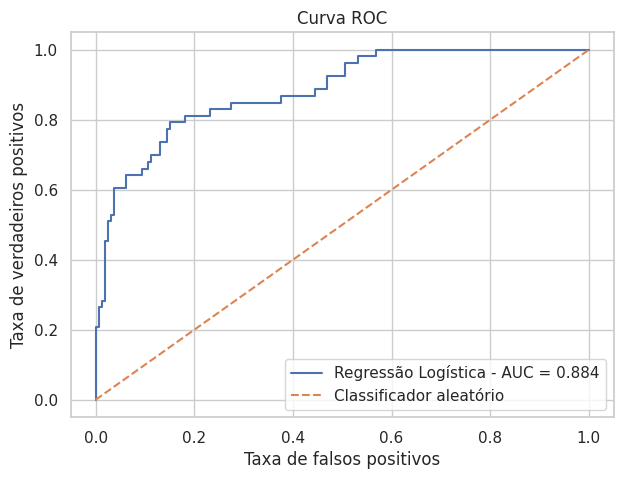

In [ ]:
# ------------------------------------------------------------
# 13) Curva ROC da Regressão Logística
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test_clf, score_logistico)
#thresholds contém os diferentes limiares de decisão testados para
#construir a curva ROC.
auc_logistico = roc_auc_score(y_test_clf, score_logistico)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Regressão Logística - AUC = {auc_logistico:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classificador aleatório")
plt.title("Curva ROC")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.show()

### Interpretação
A figura apresenta a **curva ROC** para um modelo de **Regressão Logística**, com:

```text
AUC = 0.884
```

Esse resultado indica que o modelo tem **boa capacidade de separação entre as classes**.

## Interpretação da curva

A curva azul representa o desempenho da Regressão Logística para diferentes limiares de classificação. O eixo horizontal mostra a:

$$
\text{Taxa de falsos positivos} = \frac{FP}{FP + TN}
$$

e o eixo vertical mostra a:

$$
\text{Taxa de verdadeiros positivos} = \frac{TP}{TP + FN}
$$

Ou seja, a curva mostra o compromisso entre:

```text
- detectar corretamente os casos positivos;
- evitar classificar casos negativos como positivos.
```

No contexto de um problema industrial, se a classe positiva for **processo crítico**, a curva mostra como o modelo se comporta ao tentar identificar processos críticos, aceitando mais ou menos falsos alarmes.

## Comparação com o classificador aleatório

A linha tracejada laranja representa um **classificador aleatório**. Um modelo sem capacidade real de separação ficaria próximo dessa diagonal, com AUC perto de:

```text
0.5
```

Como a curva azul está bem acima da linha aleatória, o modelo está claramente aprendendo padrões úteis nos dados.

## Interpretação do AUC = 0.884

O valor de AUC igual a **0.884** é considerado bom. Ele indica que o modelo tem alta capacidade de atribuir escores maiores aos exemplos positivos do que aos negativos.

Em termos práticos:

> O modelo consegue distinguir bem entre as classes Normal e Crítico.

Como o AUC está próximo de 0.9, a Regressão Logística apresenta desempenho bastante superior ao acaso.

## Observação sobre o formato da curva

A curva sobe rapidamente no início. Isso é positivo, pois indica que o modelo consegue alcançar uma boa taxa de verdadeiros positivos mesmo mantendo uma taxa relativamente baixa de falsos positivos.

Por exemplo, visualmente, com uma taxa de falsos positivos próxima de `0.10`, o modelo já parece alcançar uma taxa de verdadeiros positivos em torno de `0.65` a `0.70`. Com uma taxa de falsos positivos em torno de `0.20`, a taxa de verdadeiros positivos se aproxima de `0.80`.

Isso sugere que o modelo consegue capturar muitos casos positivos sem gerar falsos positivos excessivos, dependendo do limiar escolhido.

## Conclusão

A curva ROC indica que a **Regressão Logística teve bom desempenho classificatório**, com **AUC = 0.884**. O modelo é muito melhor que um classificador aleatório e apresenta boa capacidade para separar as classes.

No entanto, a curva ROC não define sozinha qual limiar deve ser usado. Para uma aplicação industrial, a escolha do limiar deve considerar o custo dos erros:

```text
- se for mais grave deixar passar um processo crítico, prioriza-se maior recall;
- se for mais grave gerar muitos alarmes falsos, prioriza-se maior precision.
```

Assim, o modelo é promissor, mas o limiar final de classificação deve ser escolhido de acordo com o objetivo operacional.


In [ ]:
'''
#--------------------------------------------------------------------------------
#Avaliando Liminares
#--------------------------------------------------------------------------------
def avaliar_classificacao(nome_modelo, modelo, X_train, X_test, y_train, y_test,limiar=0.5):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:, 1]
        if(limiar):
          y_pred = (y_score >= limiar).astype(int)
        auc = roc_auc_score(y_test, y_score)
    else:
        y_score = None
        auc = np.nan

    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    resultados_classificacao.append({
        "modelo": nome_modelo,
        "acuracia": acuracia,
        "precisao": precisao,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    })

    print(f"Modelo: {nome_modelo}")
    print(f"Acurácia: {acuracia:.3f}")
    print(f"Precisão: {precisao:.3f}")
    print(f"Recall  : {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print(f"AUC     : {auc:.3f}")

    print("\nMatriz de confusão:")
    display(pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=["Real normal", "Real crítico"],
        columns=["Previsto normal", "Previsto crítico"]
    ))

    return modelo, y_pred, y_score

# ------------------------------------------------------------
# 12) Regressão Logística
# ------------------------------------------------------------

modelo_logistico = LogisticRegression(
    max_iter=2000,
    random_state=42
)

values = [0.2,0.3,0.4,0.5]
for value in values:
  print(f"Limiar: {value}")
  modelo_logistico, pred_logistico, score_logistico = avaliar_classificacao(
      nome_modelo="Regressão Logística",
      modelo=modelo_logistico,
      X_train=X_train_clf_scaled,
      X_test=X_test_clf_scaled,
      y_train=y_train_clf,
      y_test=y_test_clf,
      limiar = value
  )

  print("\nRelatório de classificação:")
  print(classification_report(
      y_test_clf,
      pred_logistico,
      target_names=["Normal", "Crítico"],
      zero_division=0
  ))
'''

'\n#--------------------------------------------------------------------------------\n#Avaliando Liminares\n#--------------------------------------------------------------------------------\ndef avaliar_classificacao(nome_modelo, modelo, X_train, X_test, y_train, y_test,limiar=0.5):\n    modelo.fit(X_train, y_train)\n    y_pred = modelo.predict(X_test)\n\n    if hasattr(modelo, "predict_proba"):\n        y_score = modelo.predict_proba(X_test)[:, 1]\n        if(limiar):\n          y_pred = (y_score >= limiar).astype(int)\n        auc = roc_auc_score(y_test, y_score)\n    else:\n        y_score = None\n        auc = np.nan\n\n    acuracia = accuracy_score(y_test, y_pred)\n    precisao = precision_score(y_test, y_pred, zero_division=0)\n    recall = recall_score(y_test, y_pred, zero_division=0)\n    f1 = f1_score(y_test, y_pred, zero_division=0)\n\n    resultados_classificacao.append({\n        "modelo": nome_modelo,\n        "acuracia": acuracia,\n        "precisao": precisao,\n        "

# Parte 4 — Árvore de Decisão

Árvores de decisão podem ser usadas para regressão e classificação.

Elas criam regras do tipo:

```text
se vibração > limite, então maior risco de defeitos
```

Parâmetros importantes:

- `max_depth`: profundidade máxima;
- `min_samples_leaf`: mínimo de amostras em uma folha;
- `random_state`: reprodutibilidade.

Árvores muito profundas podem sofrer overfitting.

In [ ]:
# ------------------------------------------------------------
# 14) Árvore de Decisão
# ------------------------------------------------------------

arvore_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=15,
    random_state=42
)

arvore_reg, pred_arvore_reg = avaliar_regressao(
    nome_modelo="Árvore de Decisão Regressão",
    modelo=arvore_reg,
    X_train=X_train_reg_enc,
    X_test=X_test_reg_enc,
    y_train=y_train_reg,
    y_test=y_test_reg
)

print("\n" + "-" * 50 + "\n")

arvore_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=15,
    random_state=42
)

arvore_clf, pred_arvore_clf, score_arvore_clf = avaliar_classificacao(
    nome_modelo="Árvore de Decisão Classificação",
    modelo=arvore_clf,
    X_train=X_train_clf_enc,
    X_test=X_test_clf_enc,
    y_train=y_train_clf,
    y_test=y_test_clf
)

print("\nRelatório de classificação:")
print(classification_report(
      y_test_clf,
      pred_arvore_clf,
      target_names=["Normal", "Crítico"],
      zero_division=0
  ))


Modelo: Árvore de Decisão Regressão
MAE : 1.095
RMSE: 1.347
R²  : 0.244

--------------------------------------------------

Modelo: Árvore de Decisão Classificação
Acurácia: 0.775
Precisão: 0.545
Recall  : 0.566
F1-score: 0.556
AUC     : 0.796

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,135,25
Real crítico,23,30



Relatório de classificação:
              precision    recall  f1-score   support

      Normal       0.85      0.84      0.85       160
     Crítico       0.55      0.57      0.56        53

    accuracy                           0.77       213
   macro avg       0.70      0.70      0.70       213
weighted avg       0.78      0.77      0.78       213



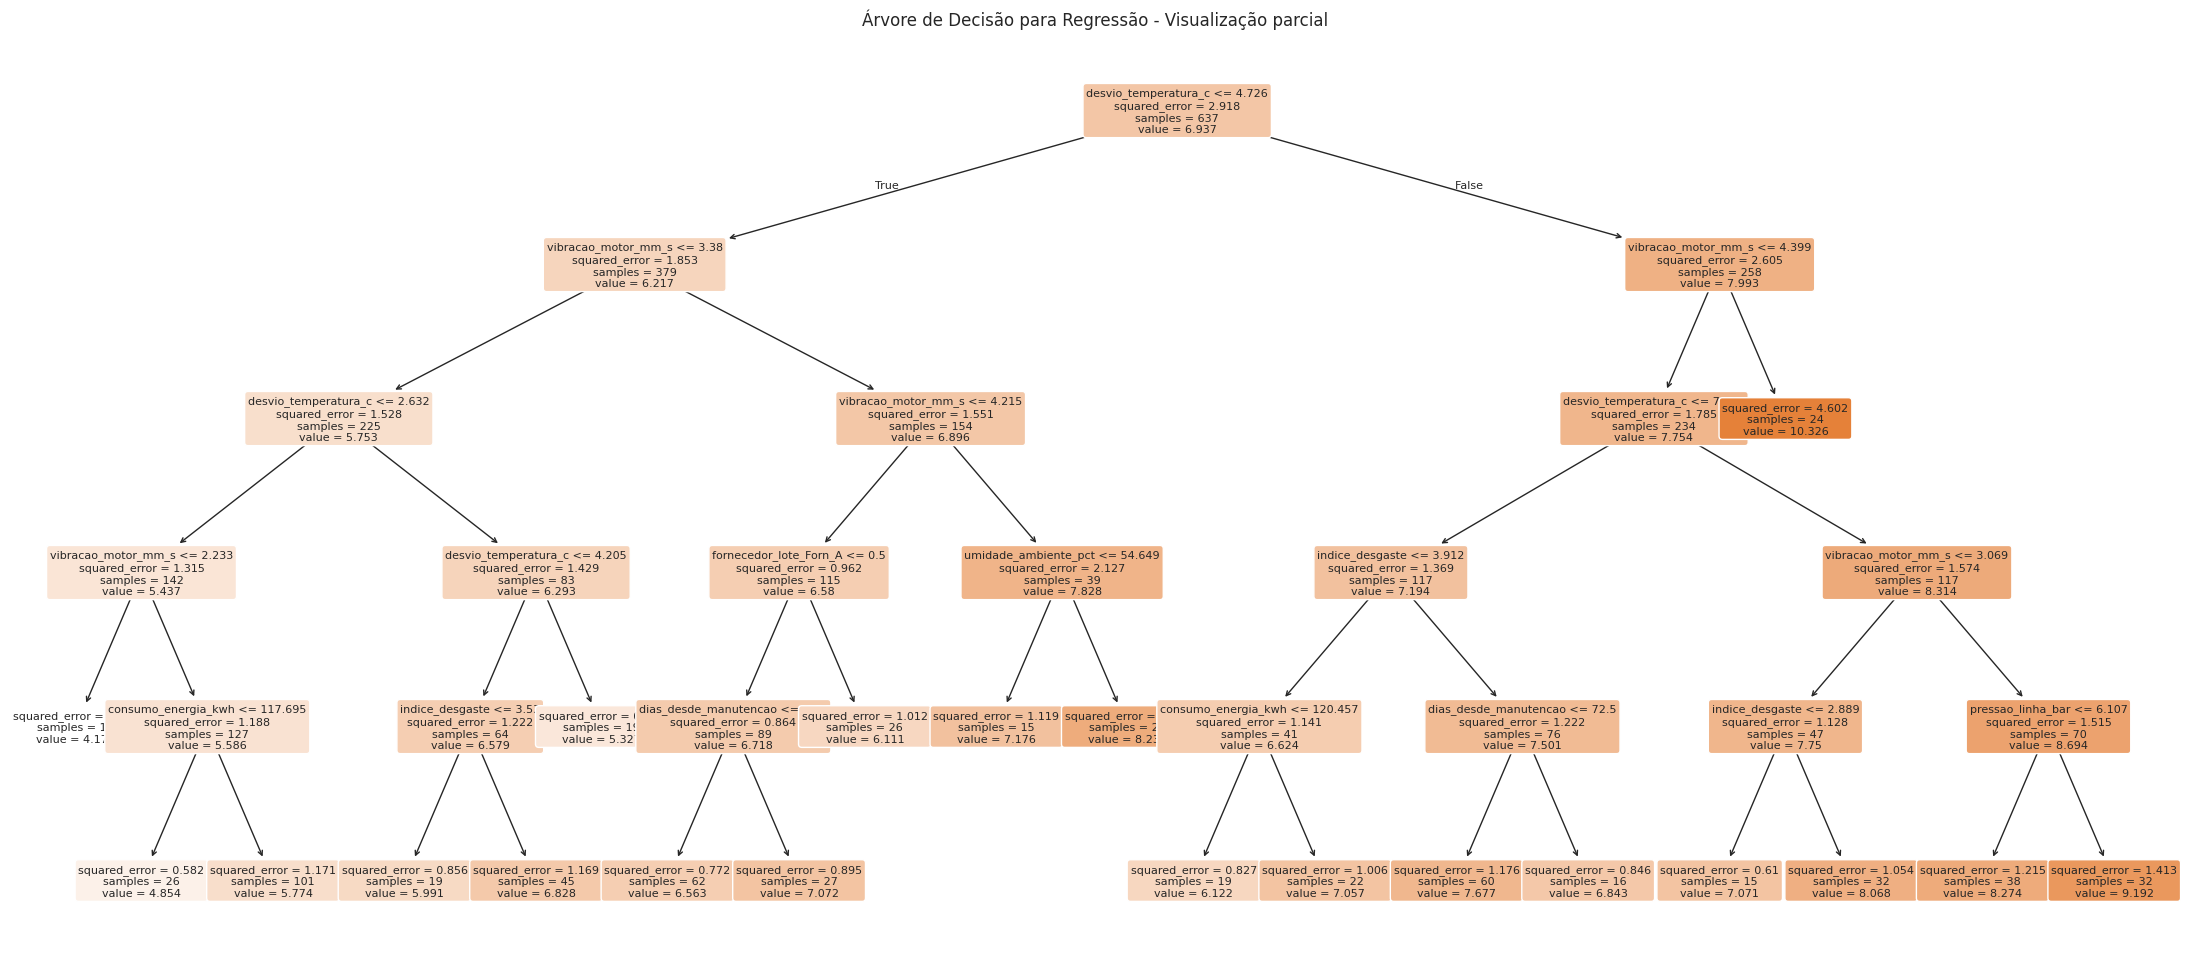

In [ ]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Visualização da Árvore de Decisão para Regressão
# ------------------------------------------------------------

nomes_atributos_reg = list(X_train_reg_enc.columns)

plt.figure(figsize=(28, 12))

plot_tree(
    arvore_reg,
    feature_names=nomes_atributos_reg,
    filled=True,#colore os nós da árvore
    rounded=True,#deixa o caixa dos nós arredondada
    impurity=True,#mostra a média de impureza do nó (squared_erro)
    fontsize=8,
    max_depth=5
)

plt.title("Árvore de Decisão para Regressão - Visualização parcial")
plt.show()

### Interpretação
A árvore apresentada é uma **Árvore de Decisão para Regressão**. Portanto, ela não prevê classes, mas sim um **valor numérico**, que neste caso é a previsão da `taxa_defeitos_pct`.

Cada nó deve ser lido assim:

```text id="st3miv"
atributo <= limiar
squared_error = erro quadrático dentro do nó
samples = quantidade de observações no nó
value = valor médio previsto da taxa de defeitos
```

No nó inicial da árvore, temos:

```text id="fzud55"
desvio_temperatura_c <= 4.726
samples = 637
value = 6.937
```

Isso significa que, considerando todas as observações de treino, a taxa média de defeitos prevista é de aproximadamente **6,94%**. A primeira variável usada para dividir os dados foi `desvio_temperatura_c`, indicando que o **desvio de temperatura** foi o atributo mais importante para iniciar a separação dos grupos.

## Interpretação dos principais ramos

A árvore separa inicialmente os dados em dois grandes grupos.

### 1. Quando o desvio de temperatura é menor ou igual a 4.726

Esse ramo representa situações mais controladas termicamente:

```text id="f0rv9x"
desvio_temperatura_c <= 4.726
samples = 379
value = 6.217
```

A previsão média cai de **6,94%** para **6,22%**. Isso sugere que menores desvios de temperatura estão associados a menor taxa de defeitos.

Depois, a árvore usa:

```text id="gfxe7t"
vibracao_motor_mm_s <= 3.38
```

Ou seja, dentro dos casos com menor desvio de temperatura, a **vibração do motor** passa a ser um fator importante.

Um caminho de menor risco é:

```text id="v6ubf8"
desvio_temperatura_c <= 4.726
vibracao_motor_mm_s <= 3.38
desvio_temperatura_c <= 2.632
vibracao_motor_mm_s <= 2.233
```

Nesse conjunto de condições, os valores previstos ficam entre aproximadamente **4,85% e 5,77%**, dependendo de divisões adicionais, como `consumo_energia_kwh`.

Isso indica que:

> Baixo desvio de temperatura, baixa vibração e menor consumo de energia estão associados a menores taxas previstas de defeitos.

---

### 2. Quando o desvio de temperatura é maior que 4.726

Esse ramo representa situações mais críticas:

```text id="kf0j7i"
desvio_temperatura_c > 4.726
samples = 258
value = 7.993
```

A previsão média sobe para aproximadamente **7,99%**. Isso mostra que valores maiores de desvio de temperatura estão associados a maior taxa de defeitos.

Nesse ramo, a árvore novamente usa a vibração:

```text id="yhl1ch"
vibracao_motor_mm_s <= 4.399
```

O caso mais crítico aparece quando a vibração é maior que esse limite:

```text id="zomrw1"
desvio_temperatura_c > 4.726
vibracao_motor_mm_s > 4.399
samples = 24
value = 10.326
```

Esse é o grupo com maior taxa prevista de defeitos na árvore: aproximadamente **10,33%**.

A interpretação industrial é clara:

> Quando o processo apresenta alto desvio de temperatura e alta vibração do motor, a árvore prevê uma taxa de defeitos substancialmente maior.

---

## Variáveis mais relevantes na árvore

Pela estrutura da árvore, os atributos mais importantes parecem ser:

```text id="kyrq9u"
desvio_temperatura_c
vibracao_motor_mm_s
indice_desgaste
consumo_energia_kwh
dias_desde_manutencao
umidade_ambiente_pct
pressao_linha_bar
fornecedor_lote_Forn_A
```

Os dois atributos que mais aparecem nos níveis superiores são:

```text id="r11441"
desvio_temperatura_c
vibracao_motor_mm_s
```

Isso é importante porque divisões próximas da raiz geralmente têm maior impacto na explicação do modelo.

## Exemplos de regras extraídas da árvore

Uma regra associada a menor taxa de defeitos seria:

```text id="wj01mb"
Se desvio_temperatura_c <= 4.726
e vibracao_motor_mm_s <= 3.38
e desvio_temperatura_c <= 2.632
então a taxa prevista de defeitos tende a ser menor.
```

Uma regra associada a maior taxa de defeitos seria:

```text id="hfb2bz"
Se desvio_temperatura_c > 4.726
e vibracao_motor_mm_s > 4.399
então a taxa prevista de defeitos é aproximadamente 10.326%.
```

Outro grupo de risco elevado aparece quando há maior desvio de temperatura, vibração ainda relevante e maior pressão de linha:

```text id="fdeb4j"
desvio_temperatura_c > 4.726
vibracao_motor_mm_s <= 4.399
vibracao_motor_mm_s > 3.069
pressao_linha_bar > 6.107
value = 9.192
```

Nesse caso, a previsão também é alta, em torno de **9,19%**.

## Conclusão

A árvore sugere que a `taxa_defeitos_pct` aumenta principalmente quando há **maior desvio de temperatura** e **maior vibração do motor**. Esses dois atributos aparecem nos primeiros níveis da árvore e organizam os principais grupos de risco.

Do ponto de vista interpretativo, a árvore é bastante útil, pois permite transformar o modelo em regras operacionais. Por exemplo:

> Processos com baixo desvio de temperatura e baixa vibração tendem a apresentar menor taxa de defeitos, enquanto processos com alto desvio de temperatura e alta vibração tendem a apresentar taxas de defeitos mais elevadas.

Entretanto, como vimos anteriormente, essa árvore teve desempenho preditivo inferior ao Lasso. Assim, ela é útil para **interpretação das relações**, mas não foi o melhor modelo em termos de erro de previsão neste experimento.


## 13. Importância dos atributos na árvore

Árvores calculam uma medida de importância de atributos:

```python
modelo.feature_importances_
```

Essa medida indica quanto cada atributo ajudou nas divisões da árvore.

,atributo,importancia
1,desvio_temperatura_c,0.480
4,vibracao_motor_mm_s,0.355
2,pressao_linha_bar,0.045
5,umidade_ambiente_pct,0.035
9,indice_desgaste,0.031
6,consumo_energia_kwh,0.027
22,fornecedor_lote_Forn_E,0.024
0,temperatura_forno_c,0.003
3,velocidade_esteira_m_min,0.000
8,dias_desde_manutencao,0.000


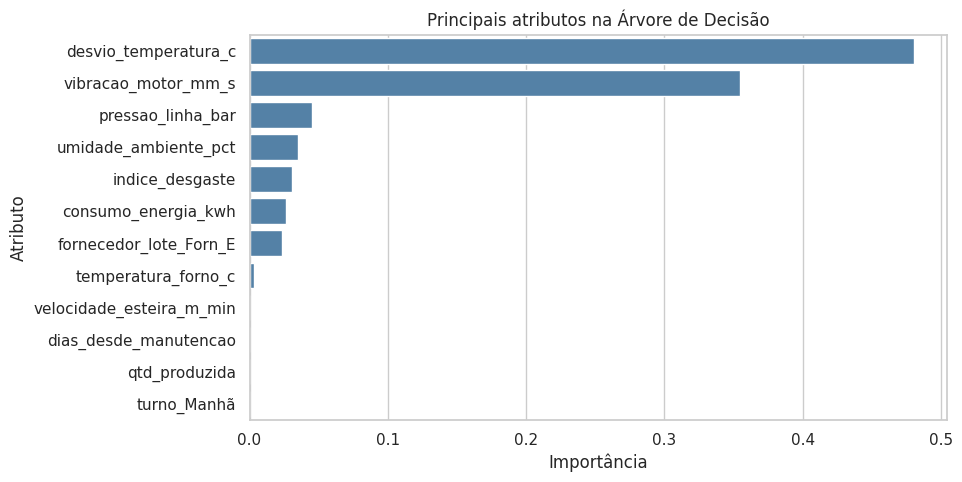

In [ ]:
# ------------------------------------------------------------
# 15) Importância de atributos
# ------------------------------------------------------------

importancias_arvore = pd.DataFrame({
    "atributo": X_train_clf_enc.columns,
    "importancia": arvore_clf.feature_importances_
}).sort_values("importancia", ascending=False)

display(importancias_arvore.head(12))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=importancias_arvore.head(12),
    x="importancia",
    y="atributo",
    color="steelblue"
)
plt.title("Principais atributos na Árvore de Decisão")
plt.xlabel("Importância")
plt.ylabel("Atributo")
plt.show()

# Parte 5 — Floresta Aleatória

A Floresta Aleatória combina várias árvores de decisão.

- Em regressão, combina as previsões das árvores.
- Em classificação, combina votos ou probabilidades.

Parâmetros importantes:

- `n_estimators`: número de árvores;
- `max_depth`: profundidade máxima;
- `min_samples_leaf`: mínimo de amostras por folha;
- `n_jobs=-1`: usa todos os núcleos disponíveis.

In [ ]:
# ------------------------------------------------------------
# 16) Floresta Aleatória
# ------------------------------------------------------------

rf_reg = RandomForestRegressor(
    n_estimators=80,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_reg, pred_rf_reg = avaliar_regressao(
    nome_modelo="Random Forest Regressão",
    modelo=rf_reg,
    X_train=X_train_reg_enc,
    X_test=X_test_reg_enc,
    y_train=y_train_reg,
    y_test=y_test_reg
)

print("\n" + "-" * 50 + "\n")

rf_clf = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_clf, pred_rf_clf, score_rf_clf = avaliar_classificacao(
    nome_modelo="Random Forest Classificação",
    modelo=rf_clf,
    X_train=X_train_clf_enc,
    X_test=X_test_clf_enc,
    y_train=y_train_clf,
    y_test=y_test_clf
)

Modelo: Random Forest Regressão
MAE : 0.964
RMSE: 1.188
R²  : 0.412

--------------------------------------------------

Modelo: Random Forest Classificação
Acurácia: 0.817
Precisão: 0.719
Recall  : 0.434
F1-score: 0.541
AUC     : 0.828

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,151,9
Real crítico,30,23


### Interpretação

A Floresta Aleatória geralmente é mais estável do que uma árvore única.

Ela é uma boa referência para bases tabulares, mas é menos interpretável do que uma única árvore.

# Parte 6 — XGBoost

O XGBoost é um ensemble baseado em boosting.

No boosting, os modelos são treinados em sequência. Cada novo modelo tenta corrigir erros dos modelos anteriores.

Parâmetros importantes:

- `n_estimators`: número de árvores;
- `learning_rate`: tamanho do passo de aprendizado;
- `max_depth`: profundidade das árvores;
- `subsample`: fração de amostras usada;
- `colsample_bytree`: fração de atributos usada por árvore.

Nesta aula, usamos valores moderados para fins didáticos.

In [ ]:
# ------------------------------------------------------------
# 17) XGBoost
# ------------------------------------------------------------

xgb_reg = XGBRegressor(
    #o modelo construirá 80 árvores de decisão sequenciais
    #durante o processo de boosting.
    n_estimators=80,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.9,
    # usa 90% das observações disponíveis para treinar cada árvore
    colsample_bytree=0.9,
    # usa 90% dos atributos disponíveis para construir cada árvore
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_reg, pred_xgb_reg = avaliar_regressao(
    nome_modelo="XGBoost Regressão",
    modelo=xgb_reg,
    X_train=X_train_reg_enc,
    X_test=X_test_reg_enc,
    y_train=y_train_reg,
    y_test=y_test_reg
)

print("\n" + "-" * 50 + "\n")

xgb_clf = XGBClassifier(
    n_estimators=80,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_clf, pred_xgb_clf, score_xgb_clf = avaliar_classificacao(
    nome_modelo="XGBoost Classificação",
    modelo=xgb_clf,
    X_train=X_train_clf_enc,
    X_test=X_test_clf_enc,
    y_train=y_train_clf,
    y_test=y_test_clf
)

Modelo: XGBoost Regressão
MAE : 0.904
RMSE: 1.113
R²  : 0.484

--------------------------------------------------

Modelo: XGBoost Classificação
Acurácia: 0.812
Precisão: 0.644
Recall  : 0.547
F1-score: 0.592
AUC     : 0.844

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,144,16
Real crítico,24,29


### Interpretação

O XGBoost costuma apresentar bom desempenho em bases tabulares, mas tem mais parâmetros.

Nesta aula, o objetivo não é fazer ajuste fino, mas entender que ele é um modelo de ensemble mais avançado, baseado em árvores treinadas sequencialmente.

# Parte 7 — Comparação dos modelos de regressão

Vamos comparar os modelos de regressão usando:

- **MAE**: menor é melhor;
- **RMSE**: menor é melhor;
- **R²**: maior é melhor.

A ordenação será feita pelo MAE, por ser uma métrica fácil de interpretar no contexto industrial.

,modelo,MAE,RMSE,R2
2,Lasso,0.895,1.111,0.486
1,Ridge,0.903,1.119,0.478
0,Regressão Linear,0.903,1.119,0.478
5,XGBoost Regressão,0.904,1.113,0.484
4,Random Forest Regressão,0.964,1.188,0.412
3,Árvore de Decisão Regressão,1.095,1.347,0.244


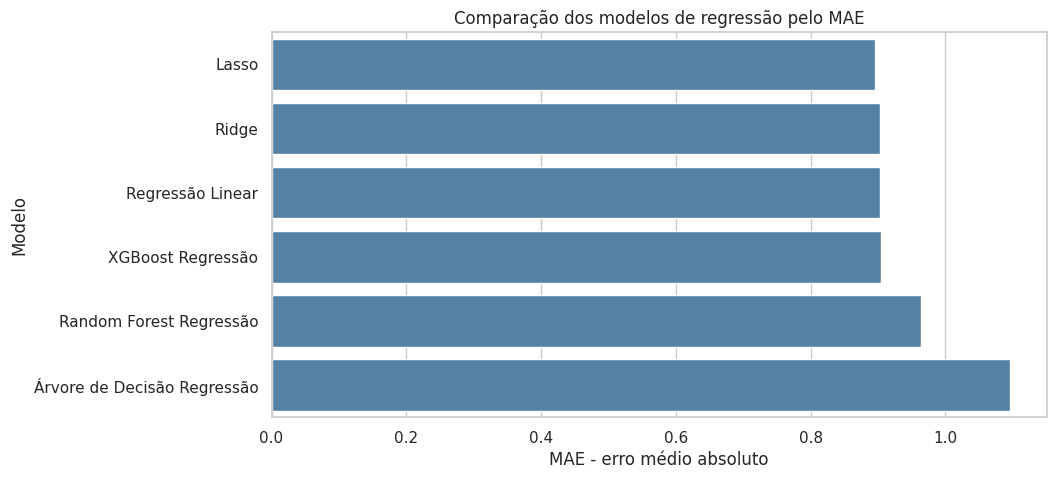

In [ ]:
# ------------------------------------------------------------
# 18) Comparação dos modelos de regressão
# ------------------------------------------------------------

tabela_regressao = pd.DataFrame(resultados_regressao).sort_values("MAE")

display(tabela_regressao.round(3))

plt.figure(figsize=(10, 5))
sns.barplot(data=tabela_regressao, x="MAE", y="modelo", color="steelblue")
plt.title("Comparação dos modelos de regressão pelo MAE")
plt.xlabel("MAE - erro médio absoluto")
plt.ylabel("Modelo")
plt.show()

### Interpretação

Os resultados mostram a comparação entre diferentes modelos de regressão para prever a `taxa_defeitos_pct`.

A tabela está ordenada pelo desempenho, e o **Lasso aparece como o melhor modelo** entre os avaliados.

| Modelo                      |   MAE |  RMSE |    R² |
| --------------------------- | ----: | ----: | ----: |
| Lasso                       | 0.895 | 1.111 | 0.486 |
| Ridge                       | 0.903 | 1.119 | 0.478 |
| Regressão Linear            | 0.903 | 1.119 | 0.478 |
| XGBoost Regressão           | 0.904 | 1.113 | 0.484 |
| Random Forest Regressão     | 0.964 | 1.188 | 0.412 |
| Árvore de Decisão Regressão | 1.095 | 1.347 | 0.244 |

## Interpretação geral

O **Lasso teve o melhor desempenho geral**, pois apresentou:

```text
menor MAE  = 0.895
menor RMSE = 1.111
maior R²   = 0.486
```

Isso significa que, em média, o Lasso erra a previsão da taxa de defeitos em aproximadamente **0,90 ponto percentual**. Além disso, ele explica cerca de **48,6% da variação observada** na taxa de defeitos.

Apesar de ser o melhor modelo da tabela, a melhora em relação à Regressão Linear e ao Ridge é pequena.

---

## Comparação entre Lasso, Ridge e Regressão Linear

Os três modelos lineares tiveram desempenhos muito parecidos:

```text
Lasso             → MAE = 0.895 | RMSE = 1.111 | R² = 0.486
Ridge             → MAE = 0.903 | RMSE = 1.119 | R² = 0.478
Regressão Linear  → MAE = 0.903 | RMSE = 1.119 | R² = 0.478
```

O **Ridge teve exatamente o mesmo desempenho da Regressão Linear**, indicando que a regularização L2 praticamente não alterou o resultado neste conjunto de teste.

O **Lasso foi ligeiramente melhor**. A diferença é pequena, mas ele tem uma vantagem adicional: como você observou antes, o Lasso zerou **9 dos 29 coeficientes**, tornando o modelo mais simples e potencialmente mais estável.

Portanto, entre os modelos lineares, o **Lasso é a opção mais interessante**, não apenas pelo desempenho, mas também pela simplificação do modelo.

---

## Comparação com XGBoost

O **XGBoost Regressão** teve desempenho muito próximo ao Lasso:

```text
Lasso             → MAE = 0.895 | RMSE = 1.111 | R² = 0.486
XGBoost Regressão → MAE = 0.904 | RMSE = 1.113 | R² = 0.484
```

A diferença é mínima. Isso mostra que, neste experimento, o XGBoost não superou o modelo linear regularizado.

Esse resultado sugere que a relação entre os atributos e a taxa de defeitos pode estar sendo razoavelmente bem capturada por modelos lineares, ou que o XGBoost ainda precisaria de melhor ajuste de hiperparâmetros para mostrar vantagem.

---

## Random Forest e Árvore de Decisão

A **Random Forest** teve desempenho inferior aos modelos lineares e ao XGBoost:

```text
Random Forest → MAE = 0.964 | RMSE = 1.188 | R² = 0.412
```

Ela ainda tem algum poder preditivo, mas explica apenas **41,2% da variação** da taxa de defeitos, abaixo do Lasso e do XGBoost.

A **Árvore de Decisão individual** foi o pior modelo da comparação:

```text
Árvore de Decisão → MAE = 1.095 | RMSE = 1.347 | R² = 0.244
```

Ela explica apenas **24,4% da variação** da taxa de defeitos. Isso indica que uma única árvore, com os parâmetros usados, não generalizou tão bem para o conjunto de teste.

Esse resultado é comum: uma árvore individual pode ser interpretável, mas pode ter desempenho inferior a modelos regularizados ou ensembles.

---

## Conclusão

O melhor resultado foi obtido pelo **Lasso**, seguido de muito perto pelo **XGBoost**. A Regressão Linear e o Ridge também tiveram desempenho bastante próximo, indicando que os modelos lineares funcionaram bem para este conjunto de dados.

A principal conclusão é:

> O Lasso foi o modelo mais adequado neste experimento, pois apresentou o menor erro, o maior R² e ainda produziu um modelo mais simples ao zerar parte dos coeficientes.

A Árvore de Decisão, embora útil para interpretação, teve o pior desempenho preditivo. Já a Random Forest ficou em uma posição intermediária, mas abaixo dos modelos lineares e do XGBoost.

Para uma conclusão mais robusta, o ideal seria repetir essa comparação com **validação cruzada**, pois os resultados atuais dependem de uma única divisão entre treino e teste.


# Parte 8 — Comparação dos modelos de classificação

Vamos comparar:

- acurácia;
- precisão;
- recall;
- F1-score;
- AUC.

A tabela será ordenada pelo F1-score, pois ele equilibra precisão e recall.

,modelo,acuracia,precisao,recall,f1_score,auc
0,Regressão Logística,0.859,0.780,0.604,0.681,0.884
3,XGBoost Classificação,0.812,0.644,0.547,0.592,0.844
1,Árvore de Decisão Classificação,0.775,0.545,0.566,0.556,0.796
2,Random Forest Classificação,0.817,0.719,0.434,0.541,0.828


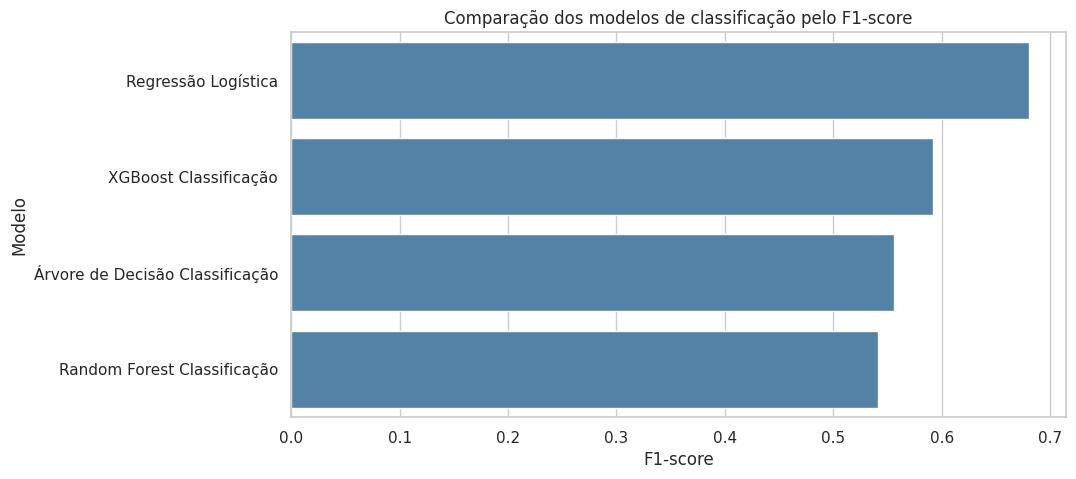

In [ ]:
# ------------------------------------------------------------
# 19) Comparação dos modelos de classificação
# ------------------------------------------------------------

tabela_classificacao = pd.DataFrame(resultados_classificacao).sort_values("f1_score", ascending=False)

display(tabela_classificacao.round(3))

plt.figure(figsize=(10, 5))
sns.barplot(data=tabela_classificacao, x="f1_score", y="modelo", color="steelblue")
plt.title("Comparação dos modelos de classificação pelo F1-score")
plt.xlabel("F1-score")
plt.ylabel("Modelo")
plt.show()

### Interpretação

A tabela compara quatro modelos de **classificação** usando as métricas: acurácia, precisão, recall, F1-score e AUC.

Os resultados são:

| Modelo                          | Acurácia | Precisão | Recall | F1-score |   AUC |
| ------------------------------- | -------: | -------: | -----: | -------: | ----: |
| Regressão Logística             |    0.859 |    0.780 |  0.604 |    0.681 | 0.884 |
| XGBoost Classificação           |    0.812 |    0.644 |  0.547 |    0.592 | 0.844 |
| Árvore de Decisão Classificação |    0.775 |    0.545 |  0.566 |    0.556 | 0.796 |
| Random Forest Classificação     |    0.817 |    0.719 |  0.434 |    0.541 | 0.828 |

## Interpretação geral

A **Regressão Logística foi o melhor modelo da comparação**. Ela apresentou a maior acurácia, maior precisão, maior F1-score e maior AUC.

```text
Regressão Logística
acurácia = 0.859
precisão = 0.780
recall   = 0.604
F1-score = 0.681
AUC      = 0.884
```

Isso indica que o modelo teve bom desempenho geral para separar as classes **Normal** e **Crítico**.

## Regressão Logística

A Regressão Logística obteve a melhor combinação de métricas.

A acurácia de **0.859** indica que o modelo acertou aproximadamente **85,9%** das classificações.

A precisão de **0.780** indica que, quando o modelo classificou um processo como **Crítico**, ele estava correto em cerca de **78%** dos casos.

O recall de **0.604** mostra que o modelo identificou aproximadamente **60,4%** dos casos realmente críticos. Isso significa que ainda deixou passar cerca de **39,6%** dos casos críticos.

O AUC de **0.884** é um resultado bom, indicando que a Regressão Logística tem boa capacidade de separar processos normais e críticos.

## XGBoost Classificação

O XGBoost ficou em segundo lugar geral.

```text
XGBoost
acurácia = 0.812
precisão = 0.644
recall   = 0.547
F1-score = 0.592
AUC      = 0.844
```

Ele teve AUC alto, de **0.844**, indicando boa capacidade de separação entre as classes. Porém, suas métricas de classificação direta ficaram abaixo da Regressão Logística.

Isso pode indicar que o XGBoost consegue ordenar bem os exemplos por risco, mas o limiar de classificação usado, provavelmente `0.5`, talvez não esteja produzindo a melhor separação final entre Normal e Crítico.

## Árvore de Decisão

A Árvore de Decisão teve desempenho inferior à Regressão Logística e ao XGBoost.

```text
Árvore de Decisão
acurácia = 0.775
precisão = 0.545
recall   = 0.566
F1-score = 0.556
AUC      = 0.796
```

Ela apresentou recall um pouco maior que o XGBoost, mas precisão menor. Isso significa que ela conseguiu capturar uma fração razoável dos casos críticos, mas gerou mais falsos positivos.

Em outras palavras, a árvore pode estar classificando mais casos como críticos, mas nem todos realmente são críticos.

## Random Forest

A Random Forest teve acurácia razoável, de **0.817**, e precisão relativamente alta, de **0.719**. Porém, teve o menor recall:

```text
Random Forest
recall = 0.434
```

Isso significa que ela deixou passar muitos casos realmente críticos.

Apesar de ter boa precisão, a Random Forest foi mais conservadora ao classificar casos como críticos. Quando ela alerta, costuma acertar mais do que a árvore simples, mas alerta menos vezes.

## Conclusão

A **Regressão Logística foi o melhor modelo neste experimento**, pois apresentou o melhor equilíbrio geral entre acurácia, precisão, recall, F1-score e AUC.

O resultado sugere que, para este conjunto de dados, um modelo linear foi mais eficiente que os modelos baseados em árvores. Além disso, a Regressão Logística apresentou AUC de **0.884**, indicando boa capacidade de separação entre processos normais e críticos.

No entanto, o recall de **0.604** mostra que o modelo ainda deixa passar uma parte dos processos críticos. Se o objetivo industrial for **não perder casos críticos**, pode ser interessante ajustar o limiar de decisão para aumentar o recall, mesmo que isso reduza um pouco a precisão.


## 14. Curvas ROC comparadas

Agora vamos comparar as curvas ROC dos modelos de classificação.

A curva ROC mostra o desempenho para diferentes limiares de classificação.

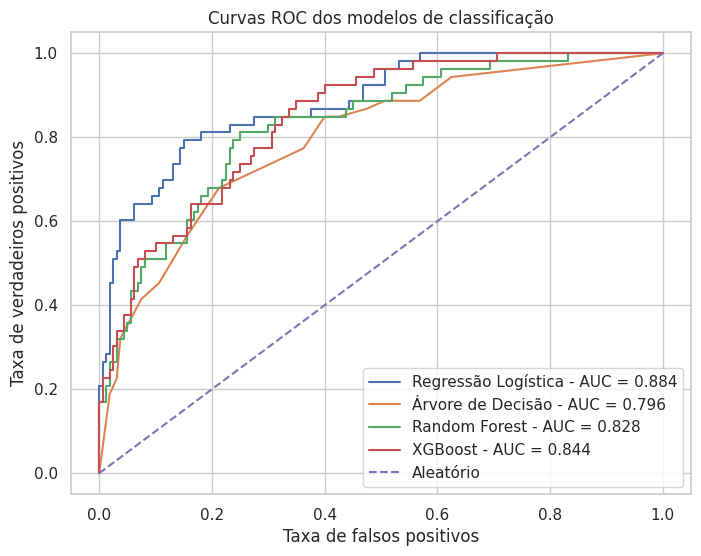

In [ ]:
# ------------------------------------------------------------
# 20) Curvas ROC comparadas
# ------------------------------------------------------------

scores_modelos = {
    "Regressão Logística": score_logistico,
    "Árvore de Decisão": score_arvore_clf,
    "Random Forest": score_rf_clf,
    "XGBoost": score_xgb_clf
}

plt.figure(figsize=(8, 6))

for nome, score in scores_modelos.items():
    fpr, tpr, _ = roc_curve(y_test_clf, score)
    auc = roc_auc_score(y_test_clf, score)
    plt.plot(fpr, tpr, label=f"{nome} - AUC = {auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
plt.title("Curvas ROC dos modelos de classificação")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.legend()
plt.show()

### Interpretação

Os valores de AUC apresentados são:

```text
Regressão Logística : AUC = 0.884
XGBoost             : AUC = 0.844
Random Forest       : AUC = 0.828
Árvore de Decisão   : AUC = 0.796
Aleatório           : AUC ≈ 0.500
```

A **Regressão Logística** apresentou o melhor desempenho geral, com **AUC = 0.884**. Isso indica que ela tem a melhor capacidade de separar as classes, por exemplo, distinguir processos **Normais** de processos **Críticos**.

A curva azul da Regressão Logística sobe rapidamente no início, o que é positivo. Isso significa que o modelo consegue alcançar uma taxa alta de verdadeiros positivos mesmo com uma taxa relativamente baixa de falsos positivos.

## XGBoost

O **XGBoost** aparece como o segundo melhor modelo, com:

```text
AUC = 0.844
```

Esse valor também indica boa capacidade de separação. A curva vermelha fica acima da linha aleatória e próxima da curva da Regressão Logística em várias regiões, mas ainda abaixo dela na maior parte do gráfico.

Isso confirma o que a tabela anterior já sugeria: o XGBoost é competitivo, mas não superou a Regressão Logística neste conjunto de dados.

## Random Forest

A **Random Forest** obteve:

```text
AUC = 0.828
```

O desempenho também é bom, mas inferior ao da Regressão Logística e ao do XGBoost. A curva verde mostra que o modelo separa as classes melhor do que o acaso, mas não alcança a mesma taxa de verdadeiros positivos da Regressão Logística para baixos níveis de falsos positivos.

Isso ajuda a explicar por que, na tabela anterior, a Random Forest teve precisão razoável, mas recall mais baixo.

## Árvore de Decisão

A **Árvore de Decisão** teve o menor AUC entre os modelos avaliados:

```text
AUC = 0.796
```

Ainda é melhor do que um classificador aleatório, mas sua capacidade de separação é menor. Isso é esperado em muitos casos, pois uma única árvore pode ser mais instável e menos robusta do que modelos de ensemble ou modelos regularizados.

## Conclusão

A curva ROC confirma que a **Regressão Logística foi o melhor modelo de classificação neste experimento**. Ela apresentou a maior AUC e a curva mais próxima do canto superior esquerdo.

A ordem geral de desempenho foi:

```text
1. Regressão Logística
2. XGBoost
3. Random Forest
4. Árvore de Decisão
```

Assim, para este conjunto de dados, a Regressão Logística teve a melhor capacidade de separar as classes. No entanto, se o objetivo operacional for reduzir falsos negativos, por exemplo, não deixar passar processos críticos, ainda seria importante ajustar o limiar de decisão e analisar métricas como recall, precision e F1-score.


# Parte 9 — Introdução ao `Pipeline`

Até aqui, fizemos tudo manualmente para entender cada etapa.

Agora vamos usar `Pipeline`.

Um `Pipeline` organiza o fluxo:

```text
pré-processamento → modelo
```

Vantagens:

- reduz repetição de código;
- diminui risco de aplicar transformações erradas;
- ajuda a evitar vazamento de dados;
- facilita comparar modelos.

Usaremos também `ColumnTransformer` para aplicar:

- `StandardScaler` nos atributos numéricos;
- `OneHotEncoder` nos atributos categóricos.

##**Pipeline do scikit-learn**

```python
pipeline_ridge = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train_reg, y_train_reg)

pred_pipeline_ridge = pipeline_ridge.predict(X_test_reg)

```

Pipeline junta, em uma única estrutura, duas etapas fundamentais de um modelo de aprendizado de máquina:

1. **pré-processamento dos dados**;
2. **treinamento e uso do modelo de regressão Ridge**.

A ideia central é evitar fazer manualmente várias transformações separadas e reduzir o risco de **data leakage**, isto é, usar informações do conjunto de teste durante o treinamento.

---

## 1. Criação do pré-processador

```python
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), atributos_numericos),
        ("cat", criar_onehot(), atributos_categoricos)
    ]
)
```

Aqui é criado um objeto chamado `preprocessador`.

Ele usa `ColumnTransformer`, que permite aplicar transformações diferentes para grupos diferentes de colunas.

No caso:

```python
("num", StandardScaler(), atributos_numericos)
```

significa:

> aplique `StandardScaler()` nas colunas numéricas.

O `StandardScaler()` transforma os atributos numéricos para terem, aproximadamente:

```text
média = 0
desvio padrão = 1
```

Isso é importante para modelos como Ridge, porque eles são sensíveis à escala das variáveis.

Por exemplo, uma variável como `temperatura_motor` pode variar de 60 a 120, enquanto outra como `vibracao` pode variar de 0 a 10. A padronização evita que uma variável domine a outra apenas por ter valores maiores.

---

Já esta parte:

```python
("cat", criar_onehot(), atributos_categoricos)
```

significa:

> aplique codificação One-Hot nas colunas categóricas.

A função `criar_onehot()`, descrita no código, retorna um `OneHotEncoder`, por exemplo:

```python
OneHotEncoder(handle_unknown="ignore")
```

Esse transformador converte categorias em colunas binárias.

Por exemplo, uma variável como:

```text
turno = manhã, tarde, noite
```

pode virar:

```text
turno_manhã | turno_tarde | turno_noite
```

com valores `0` ou `1`.

---

## 2. Criação do pipeline

```python
pipeline_ridge = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", Ridge(alpha=1.0))
])
```

Aqui é criado o pipeline propriamente dito.

Ele define uma sequência de etapas:

```text
Dados brutos
   ↓
Pré-processamento
   ↓
Modelo Ridge
   ↓
Previsões
```

A primeira etapa é:

```python
("preprocessamento", preprocessador)
```

Essa etapa aplica:

* padronização nas variáveis numéricas;
* One-Hot Encoding nas variáveis categóricas.

A segunda etapa é:

```python
("modelo", Ridge(alpha=1.0))
```

Essa etapa treina um modelo de **regressão Ridge**.

A Ridge é uma regressão linear com regularização. O parâmetro:

```python
alpha=1.0
```

controla a força da penalização aplicada aos coeficientes do modelo. Quanto maior o `alpha`, mais o modelo tenta reduzir os coeficientes, ajudando a evitar sobreajuste.

---

## 3. Treinamento do pipeline

```python
pipeline_ridge.fit(X_train_reg, y_train_reg)
```

Quando esse comando é executado, o pipeline faz tudo automaticamente.

Primeiro, ele ajusta o pré-processamento usando apenas os dados de treino:

```python
X_train_reg
```

Ou seja:

* o `StandardScaler` calcula média e desvio padrão apenas no treino;
* o `OneHotEncoder` aprende as categorias apenas no treino.

Depois, o modelo Ridge é treinado usando os dados já transformados.

Em termos conceituais, é como se o pipeline fizesse:

```python
X_train_transformado = preprocessador.fit_transform(X_train_reg)
modelo_ridge.fit(X_train_transformado, y_train_reg)
```

Mas a vantagem é que tudo fica encapsulado em um único objeto.

---

## 4. Geração das previsões

```python
pred_pipeline_ridge = pipeline_ridge.predict(X_test_reg)
```

Aqui o pipeline recebe os dados de teste ainda no formato original.

Ele faz automaticamente:

1. aplica o mesmo pré-processamento aprendido no treino;
2. usa o modelo Ridge treinado para prever os valores.

Conceitualmente, seria algo como:

```python
X_test_transformado = preprocessador.transform(X_test_reg)
pred_pipeline_ridge = modelo_ridge.predict(X_test_transformado)
```

Mas novamente, o pipeline faz isso internamente.

---

## Por que usar Pipeline?

A principal vantagem é garantir que todas as etapas sejam aplicadas corretamente e na ordem certa.

Sem pipeline, você teria que fazer manualmente:

```python
preprocessador.fit_transform(X_train_reg)
preprocessador.transform(X_test_reg)
modelo.fit(...)
modelo.predict(...)
```

Com pipeline, basta usar:

```python
pipeline_ridge.fit(X_train_reg, y_train_reg)
pipeline_ridge.predict(X_test_reg)
```

Isso deixa o código mais organizado, mais seguro e mais fácil de reutilizar.

---

## Relação com prevenção de data leakage

Esse ponto é muito importante.

Ao usar:

```python
pipeline_ridge.fit(X_train_reg, y_train_reg)
```

o pipeline ajusta o `StandardScaler` e o `OneHotEncoder` **somente com os dados de treino**.

Depois, quando usamos:

```python
pipeline_ridge.predict(X_test_reg)
```

ele apenas aplica no teste as transformações já aprendidas.

Isso evita que informações do conjunto de teste influenciem o treinamento.

Por exemplo, seria errado calcular a média e o desvio padrão usando toda a base antes da separação treino/teste, porque o modelo teria acesso indireto a informações do teste. O pipeline ajuda a evitar esse erro.

---

## Resumo

Esse código pode ser interpretado assim:

```text
1. Separe as colunas numéricas e categóricas.
2. Nas numéricas, aplique padronização.
3. Nas categóricas, aplique One-Hot Encoding.
4. Depois das transformações, treine uma regressão Ridge.
5. Use o mesmo fluxo para fazer previsões no conjunto de teste.
```

Portanto, o `Pipeline` representa o fluxo completo de aprendizado de máquina:

```text
dados brutos → transformação → modelo → previsão
```

Ele torna o processo mais organizado, reproduzível e menos sujeito a erros.


In [ ]:
# ------------------------------------------------------------
# 21) Pipeline para regressão com Ridge
# ------------------------------------------------------------

def criar_onehot():
    try:
      # sparte_output=a saída será uma matriz densa, semelhante a um array NumPy comum.
        return OneHotEncoder(handle_unknown="ignore", sparse_output = False)

    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), atributos_numericos),
        ("cat", criar_onehot(), atributos_categoricos)
    ]
)

pipeline_ridge = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train_reg, y_train_reg)

pred_pipeline_ridge = pipeline_ridge.predict(X_test_reg)

mae_pipe = mean_absolute_error(y_test_reg, pred_pipeline_ridge)
rmse_pipe = np.sqrt(mean_squared_error(y_test_reg, pred_pipeline_ridge))
r2_pipe = r2_score(y_test_reg, pred_pipeline_ridge)

print("Pipeline Ridge")
print(f"MAE : {mae_pipe:.3f}")
print(f"RMSE: {rmse_pipe:.3f}")
print(f"R²  : {r2_pipe:.3f}")

Pipeline Ridge
MAE : 0.903
RMSE: 1.119
R²  : 0.478


## 15. Pipeline para classificação com Regressão Logística

Agora vamos montar um pipeline para classificação.

Ele terá:

- `ColumnTransformer`;
- `StandardScaler`;
- `OneHotEncoder`;
- `LogisticRegression`.

Esse formato é mais próximo de um fluxo real de projeto.

In [ ]:
# ------------------------------------------------------------
# 22) Pipeline para classificação com Regressão Logística
# ------------------------------------------------------------

pipeline_logistico = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

pipeline_logistico.fit(X_train_clf, y_train_clf)

pred_pipeline_logistico = pipeline_logistico.predict(X_test_clf)
score_pipeline_logistico = pipeline_logistico.predict_proba(X_test_clf)[:, 1]

print("Pipeline Regressão Logística")
print(f"Acurácia: {accuracy_score(y_test_clf, pred_pipeline_logistico):.3f}")
print(f"Precisão: {precision_score(y_test_clf, pred_pipeline_logistico, zero_division=0):.3f}")
print(f"Recall  : {recall_score(y_test_clf, pred_pipeline_logistico, zero_division=0):.3f}")
print(f"F1-score: {f1_score(y_test_clf, pred_pipeline_logistico, zero_division=0):.3f}")
print(f"AUC     : {roc_auc_score(y_test_clf, score_pipeline_logistico):.3f}")

print("\nMatriz de confusão:")
display(pd.DataFrame(
    confusion_matrix(y_test_clf, pred_pipeline_logistico),
    index=["Real normal", "Real crítico"],
    columns=["Previsto normal", "Previsto crítico"]
))

Pipeline Regressão Logística
Acurácia: 0.859
Precisão: 0.780
Recall  : 0.604
F1-score: 0.681
AUC     : 0.883

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,151,9
Real crítico,21,32


## 16. Comparando fluxo manual e fluxo com Pipeline

O pipeline não muda o objetivo do modelo. Ele organiza o processo.

| Fluxo manual | Fluxo com Pipeline |
|---|---|
| Mais didático no início | Mais organizado |
| Mostra cada etapa separadamente | Reduz repetição |
| Mais sujeito a erro operacional | Ajuda a evitar vazamento |
| Bom para aprender | Bom para projetos |

## Comparação entre modelos usando validação cruzada

Descrevemos a seguir alguns recursos utilizados.

```python
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

Acima é criado o esquema de validação cruzada.

`KFold` divide a base em `5` partes, chamadas *folds*. Em cada rodada, o modelo é treinado com 4 partes e testado com a parte restante.

Com `n_splits=5`, o processo ocorre assim:

| Rodada | Treino           | Teste  |
| ------ | ---------------- | ------ |
| 1      | folds 2, 3, 4, 5 | fold 1 |
| 2      | folds 1, 3, 4, 5 | fold 2 |
| 3      | folds 1, 2, 4, 5 | fold 3 |
| 4      | folds 1, 2, 3, 5 | fold 4 |
| 5      | folds 1, 2, 3, 4 | fold 5 |

O parâmetro:

```python
shuffle=True
```

embaralha os dados antes de criar os folds. Isso é útil quando os dados podem estar ordenados, por exemplo, por data, máquina, lote ou nível de produção.

O parâmetro:

```python
random_state=42
```

garante reprodutibilidade. Ou seja, sempre que o código for executado, o embaralhamento será o mesmo.

---

Depois são definidas as métricas:

```python
metricas = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}
```

Esse dicionário diz ao `cross_validate` quais métricas devem ser calculadas.

A chave, por exemplo `"MAE"`, é o nome que você quer dar à métrica no resultado.

O valor, por exemplo `"neg_mean_absolute_error"`, é o nome interno da métrica no `scikit-learn`.

Um detalhe importante: no `scikit-learn`, métricas de erro como MAE e RMSE aparecem com sinal negativo:

```python
"neg_mean_absolute_error"
"neg_root_mean_squared_error"
```

Isso acontece porque o `scikit-learn` segue a convenção de que, em validação cruzada, **quanto maior o score, melhor**.

Como MAE e RMSE são erros, e nesses casos **quanto menor, melhor**, o `scikit-learn` devolve esses valores com sinal negativo. Depois, normalmente invertemos o sinal para interpretar.

---

A validação cruzada é executada aqui:

```python
scores = cross_validate(
        estimator=modelo,
        X=X_pip,
        y=y_pip,
        scoring=metricas,
        cv=cv,
        return_train_score=False
    )
```

O argumento:

```python
estimator=modelo
```

indica qual modelo será avaliado. Esse `modelo` pode ser, por exemplo, uma regressão linear, uma árvore de decisão, uma random forest ou um `Pipeline`.

Se `modelo` for um `Pipeline`, a validação cruzada é ainda mais segura, porque o pré-processamento será ajustado separadamente em cada conjunto de treino. Isso ajuda a evitar **vazamento de dados**.

O argumento:

```python
X=X_pip
```

contém os atributos de entrada.

O argumento:

```python
y=y_pip
```

contém a variável-alvo que o modelo deve prever.

O argumento:

```python
scoring=metricas
```

indica que o modelo será avaliado usando MAE, RMSE e R².

O argumento:

```python
cv=cv
```

diz que será usada a estratégia de validação cruzada definida anteriormente com `KFold`.

O argumento:

```python
return_train_score=False
```

indica que o resultado deve conter apenas as métricas no conjunto de teste de cada fold. Ou seja, ele não retorna as métricas calculadas no treino.

Isso é comum quando o objetivo principal é avaliar a capacidade de generalização do modelo.

---

O objeto `scores` será um dicionário parecido com este:

```python
scores.keys()
```

Resultado esperado:

```python
dict_keys([
    'fit_time',
    'score_time',
    'test_MAE',
    'test_RMSE',
    'test_R2'
])
```

Cada métrica terá 5 valores, um para cada fold.

Por exemplo:

```python
scores["test_MAE"]
```

pode retornar algo como:

```python
array([-12.4, -10.8, -11.6, -13.1, -10.9])
```

Como o MAE vem negativo, a interpretação correta seria:

```python
-scores["test_MAE"]
```

---

Uma forma comum de organizar os resultados é:

```python
resultados_cv = pd.DataFrame({
    "MAE": -scores["test_MAE"],
    "RMSE": -scores["test_RMSE"],
    "R2": scores["test_R2"]
})

display(resultados_cv)

print("Média das métricas:")
display(resultados_cv.mean())
```

Assim, você obtém uma tabela como:

| Fold |            MAE |           RMSE |           R2 |
| ---- | -------------: | -------------: | -----------: |
| 1    | erro do fold 1 | erro do fold 1 | R² do fold 1 |
| 2    | erro do fold 2 | erro do fold 2 | R² do fold 2 |
| 3    | erro do fold 3 | erro do fold 3 | R² do fold 3 |
| 4    | erro do fold 4 | erro do fold 4 | R² do fold 4 |
| 5    | erro do fold 5 | erro do fold 5 | R² do fold 5 |

Em resumo, esse código avalia o desempenho médio do modelo em 5 partições diferentes da base, permitindo uma estimativa mais confiável do desempenho do que um único `train_test_split`.



In [ ]:
# ------------------------------------------------------------
# Comparação entre modelso de regressão
# usando validação cruzada
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

# ------------------------------------------------------------
# 1) Definir X e y
# ------------------------------------------------------------
# X deve conter os atributos de entrada
# y deve conter a variável-alvo: taxa_defeitos_pct

X_pip = X
y_pip = y_reg

# ------------------------------------------------------------
# 2) Definir os modelos
# ------------------------------------------------------------
# Usamos StandardScaler dentro do Pipeline para evitar data leakage.
# A padronização será ajustada apenas nos folds de treino.


preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), atributos_numericos),
        ("cat", criar_onehot(), atributos_categoricos)
    ]
)


modelos = {
    "Regressão Linear": Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("preprcessamento", preprocessador),
        ("modelo", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", Lasso(alpha=0.1, max_iter=10000))
    ]),
    "Arvore Decisao": Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", DecisionTreeRegressor(max_depth=5,
                                         min_samples_leaf=15,
                                         random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", RandomForestRegressor(n_estimators=80,
                                         max_depth=8,
                                         min_samples_leaf=5,
                                         random_state=42,
                                         n_jobs=-1))
    ]),
    "XGBoot": Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", XGBRegressor(n_estimators=80,
                                learning_rate=0.06,
                                max_depth=3,
                                subsample=0.9,
                                colsample_bytree=0.9,
                                objective="reg:squarederror",
                                random_state=42,
                                n_jobs=-1))
    ])
}

# ------------------------------------------------------------
# 3) Definir a validação cruzada
# ------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ------------------------------------------------------------
# 4) Definir métricas de avaliação
# ------------------------------------------------------------
# No scikit-learn, métricas de erro aparecem como negativas
# porque a biblioteca segue a lógica: quanto maior, melhor.
# Por isso, depois vamos multiplicar MAE e RMSE por -1.

metricas = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# ------------------------------------------------------------
# 5) Rodar a validação cruzada para cada modelo
# ------------------------------------------------------------

resultados = []

for nome_modelo, modelo in modelos.items():

    scores = cross_validate(
        estimator=modelo,
        X=X_pip,
        y=y_pip,
        scoring=metricas,
        cv=cv,
        return_train_score=False
    )

    mae_medio = -scores["test_MAE"].mean()
    mae_desvio = scores["test_MAE"].std()

    rmse_medio = -scores["test_RMSE"].mean()
    rmse_desvio = scores["test_RMSE"].std()

    r2_medio = scores["test_R2"].mean()
    r2_desvio = scores["test_R2"].std()

    resultados.append({
        "modelo": nome_modelo,
        "MAE médio": mae_medio,
        "MAE desvio": mae_desvio,
        "RMSE médio": rmse_medio,
        "RMSE desvio": rmse_desvio,
        "R² médio": r2_medio,
        "R² desvio": r2_desvio
    })

# ------------------------------------------------------------
# 6) Organizar os resultados em uma tabela
# ------------------------------------------------------------

tabela_cv = pd.DataFrame(resultados)

tabela_cv = tabela_cv.sort_values(
    by=["RMSE médio", "MAE médio"],
    ascending=[True, True]
)

display(tabela_cv)

,modelo,MAE médio,MAE desvio,RMSE médio,RMSE desvio,R² médio,R² desvio
1,Ridge,0.909,0.050,1.140,0.067,0.527,0.049
0,Regressão Linear,0.909,0.050,1.141,0.067,0.526,0.049
2,Lasso,0.930,0.037,1.166,0.059,0.507,0.026
5,XGBoot,0.920,0.049,1.170,0.085,0.505,0.028
4,Random Forest,0.949,0.041,1.199,0.069,0.479,0.031
3,Arvore Decisao,1.043,0.047,1.324,0.062,0.362,0.054


In [ ]:
melhor_modelo = tabela_cv.iloc[0]

print("Melhor modelo pela comparação com RMSE:")
print(melhor_modelo)

Melhor modelo pela comparação com RMSE:
modelo         Ridge
MAE médio      0.909
MAE desvio      0.05
RMSE médio      1.14
RMSE desvio    0.067
R² médio       0.527
R² desvio      0.049
Name: 1, dtype: object


##Seleção de hiperparâmetros com Pipeline

```python
busca_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
```

Cria uma busca automática por melhores hiperparâmetros para um modelo XGBoost dentro de um `Pipeline`.

A ideia central é:

> testar várias combinações de parâmetros do XGBoost, avaliando cada combinação por validação cruzada, e escolher aquela que produz o menor MAE médio.

---

## 1. O que entra em `estimator=pipeline_xgb`

Aqui você está dizendo ao `GridSearchCV` que o modelo a ser avaliado não é apenas o `XGBRegressor`, mas sim o pipeline completo.

Por exemplo, suponha que você tenha algo assim:

```python
pipeline_xgb = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])
```

Esse pipeline tem duas etapas:

| Etapa                | Função                                                             |
| -------------------- | ------------------------------------------------------------------ |
| `"preprocessamento"` | aplica transformações como `StandardScaler`, `OneHotEncoder`, etc. |
| `"modelo"`           | ajusta o `XGBRegressor`                                            |

Então, em cada fold da validação cruzada, o `GridSearchCV` faz:

```text
dados de treino do fold
        ↓
ajusta o preprocessamento
        ↓
transforma os dados de treino
        ↓
treina o XGBoost
        ↓
transforma os dados de validação
        ↓
avalia o erro no fold
```

Isso é importante porque evita **vazamento de dados**.

O preprocessamento é ajustado apenas com os dados de treinamento de cada fold, e não com a base inteira.

---

## 2. O que entra em `param_grid=param_grid_xgb`

O `param_grid_xgb` define quais combinações de hiperparâmetros serão testadas.

Um exemplo seria:

```python
param_grid_xgb = {
    "modelo__n_estimators": [80, 120, 200],
    "modelo__learning_rate": [0.03, 0.06, 0.1],
    "modelo__max_depth": [3, 4, 5],
    "modelo__subsample": [0.8, 0.9, 1.0],
    "modelo__colsample_bytree": [0.8, 0.9, 1.0]
}
```

Observe o uso de:

```python
"modelo__n_estimators"
```

Esse nome tem duas partes:

```text
nome_da_etapa_do_pipeline__nome_do_parametro
```

Como no pipeline o XGBoost foi chamado de `"modelo"`, os parâmetros dele precisam ser referenciados assim:

```python
"modelo__max_depth"
"modelo__learning_rate"
"modelo__n_estimators"
```

Se a etapa tivesse outro nome, por exemplo:

```python
("xgb", XGBRegressor())
```

então os parâmetros seriam:

```python
"xgb__max_depth"
"xgb__learning_rate"
```

---

## 3. O que significa `scoring="neg_mean_absolute_error"`

Aqui você define a métrica usada para comparar os modelos.

O MAE mede o erro médio absoluto:

```text
MAE = média dos erros absolutos entre valor real e valor previsto
```

Quanto menor o MAE, melhor.

Porém, no `scikit-learn`, as métricas usadas em `GridSearchCV` seguem a lógica:

```text
maior score = melhor modelo
```

Como o MAE é uma métrica de erro, e erro menor é melhor, o `scikit-learn` usa o valor negativo:

```python
scoring="neg_mean_absolute_error"
```

Então, se um modelo tem MAE igual a 10, o score registrado será:

```python
-10
```

Se outro modelo tem MAE igual a 15, o score será:

```python
-15
```

Como `-10` é maior que `-15`, o `GridSearchCV` entende corretamente que MAE 10 é melhor que MAE 15.

Por isso, depois da busca, é comum inverter o sinal:

```python
melhor_mae = -busca_xgb.best_score_
```

---

## 4. O que significa `cv=cv`

Aqui você define a estratégia de validação cruzada.

Por exemplo, se antes você definiu:

```python
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
```

então cada combinação de hiperparâmetros será avaliada em 5 folds.

Suponha que o `param_grid_xgb` tenha 20 combinações diferentes. Com `cv=5`, o processo fará:

```text
20 combinações × 5 folds = 100 treinamentos
```

Ou seja, o `GridSearchCV` treina muitos modelos internamente para descobrir qual combinação tem melhor desempenho médio.

---

## 5. O que significa `n_jobs=-1`

Esse parâmetro controla o uso de processamento paralelo.

```python
n_jobs=-1
```

significa:

> use todos os núcleos de processamento disponíveis.

Isso pode acelerar a busca, porque diferentes combinações de parâmetros e folds podem ser avaliados em paralelo.

---

## 6. O que significa `verbose=1`

Esse parâmetro controla o nível de mensagens mostradas durante a execução.

```python
verbose=1
```

faz o `GridSearchCV` imprimir algumas informações sobre o andamento da busca, por exemplo quantos ajustes serão realizados.

Valores maiores, como `verbose=2` ou `verbose=3`, mostram mais detalhes.

---

## 7. Como usar depois de criar o objeto

O código que você mostrou apenas cria o objeto da busca:

```python
busca_xgb = GridSearchCV(...)
```

A busca de fato acontece quando você executa:

```python
busca_xgb.fit(X_train_reg, y_train_reg)
```

Nesse momento, o `GridSearchCV` testa todas as combinações definidas em `param_grid_xgb`.

Depois, você pode acessar os melhores resultados:

```python
busca_xgb.best_params_
```

Retorna os melhores hiperparâmetros encontrados.

```python
busca_xgb.best_score_
```

Retorna o melhor score médio na validação cruzada. Como o MAE está negativo, você pode fazer:

```python
-busca_xgb.best_score_
```

para obter o MAE médio positivo.

```python
busca_xgb.best_estimator_
```

Retorna o melhor pipeline completo já ajustado.

Por exemplo:

```python
melhor_modelo_xgb = busca_xgb.best_estimator_
```

Depois você pode prever no conjunto de teste:

```python
pred_xgb = melhor_modelo_xgb.predict(X_test_reg)
```

---

## 8. Interpretação geral

Em resumo, este código:

```python
busca_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
```

significa:

> “Teste várias configurações do modelo XGBoost dentro de um pipeline com preprocessamento, avalie cada configuração usando validação cruzada, compare os modelos pelo MAE médio e selecione automaticamente a melhor combinação de hiperparâmetros.”

A grande vantagem de usar `GridSearchCV` com `Pipeline` é que a busca avalia o processo completo: **preprocessamento + modelo**. Isso deixa a avaliação mais correta, mais organizada e menos sujeita a vazamento de dados.


In [ ]:
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pipeline_xgb_original = Pipeline([
        ("preprocessamento", preprocessador),
        ("modelo", XGBRegressor(n_estimators=80,
                                learning_rate=0.06,
                                max_depth=3,
                                subsample=0.9,
                                colsample_bytree=0.9,
                                objective="reg:squarederror",
                                random_state=42,
                                n_jobs=-1))
    ])

pipeline_xgb_original.fit(X_train_reg, y_train_reg)

pred_xgb_original = pipeline_xgb_original.predict(X_test_reg)
mae_xgb_original = mean_absolute_error(y_test_reg, pred_xgb_original)
rmse_xgb_original = np.sqrt(mean_squared_error(y_test_reg, pred_xgb_original))
r2_xgb_original = r2_score(y_test_reg, pred_xgb_original)

print("\nXGBoost original no conjunto de teste")
print(f"MAE : {mae_xgb_original:.3f}")
print(f"RMSE: {rmse_xgb_original:.3f}")
print(f"R²  : {r2_xgb_original:.3f}")


pipeline_xgb = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("modelo", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_xgb = {
    "modelo__n_estimators": [80, 150],
    "modelo__learning_rate": [0.03, 0.06, 0.10],
    "modelo__max_depth": [2,3, 4],
    "modelo__subsample": [0.8, 0.9],
    "modelo__colsample_bytree": [0.8, 0.9],
}

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

busca_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

busca_xgb.fit(X_train_reg, y_train_reg)

melhor_xgb = busca_xgb.best_estimator_

print("Melhores hiperparâmetros:")
print(busca_xgb.best_params_)

print("\nMelhor MAE médio na validação cruzada:")
print(-busca_xgb.best_score_)

pred_xgb_otimizado = melhor_xgb.predict(X_test_reg)

mae_xgb = mean_absolute_error(y_test_reg, pred_xgb_otimizado)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, pred_xgb_otimizado))
r2_xgb = r2_score(y_test_reg, pred_xgb_otimizado)

print("\nXGBoost otimizado no conjunto de teste")
print(f"MAE : {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²  : {r2_xgb:.3f}")


XGBoost original no conjunto de teste
MAE : 0.904
RMSE: 1.113
R²  : 0.484
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Melhores hiperparâmetros:
{'modelo__colsample_bytree': 0.9, 'modelo__learning_rate': 0.06, 'modelo__max_depth': 2, 'modelo__n_estimators': 150, 'modelo__subsample': 0.8}

Melhor MAE médio na validação cruzada:
0.9068035196306669

XGBoost otimizado no conjunto de teste
MAE : 0.908
RMSE: 1.120
R²  : 0.477


# Parte 10 — Atividade orientada

Responda usando o notebook:

1. O que acontece com Ridge se `alpha` mudar de `1.0` para `10.0`?
2. O que acontece com Lasso se `alpha` aumentar?
3. A árvore melhora ou piora quando `max_depth` aumenta?
4. Qual modelo teve menor MAE no problema de regressão?
5. Qual modelo teve maior recall no problema de classificação?
6. Qual modelo teve maior AUC?
7. Em um problema industrial, você priorizaria acurácia ou recall para detectar processo crítico? Justifique.
8. O pipeline facilitou a organização do código? Em quais partes?
9. Repita o pipeline para comparação dos modelos em classificação.

In [ ]:
# ------------------------------------------------------------
# 24) Espaço para experimentação
# ------------------------------------------------------------

modelo_ridge_teste = Ridge(alpha=10.0, random_state=42)

modelo_ridge_teste, pred_ridge_teste = avaliar_regressao(
    nome_modelo="Ridge alpha=10.0 - teste",
    modelo=modelo_ridge_teste,
    X_train=X_train_reg_scaled,
    X_test=X_test_reg_scaled,
    y_train=y_train_reg,
    y_test=y_test_reg
)

print("\n" + "-" * 50 + "\n")

arvore_teste = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=15,
    random_state=42
)

arvore_teste, pred_arvore_teste, score_arvore_teste = avaliar_classificacao(
    nome_modelo="Árvore max_depth=3 - teste",
    modelo=arvore_teste,
    X_train=X_train_clf_enc,
    X_test=X_test_clf_enc,
    y_train=y_train_clf,
    y_test=y_test_clf
)

Modelo: Ridge alpha=10.0 - teste
MAE : 0.899
RMSE: 1.116
R²  : 0.481

--------------------------------------------------

Modelo: Árvore max_depth=3 - teste
Acurácia: 0.784
Precisão: 0.585
Recall  : 0.453
F1-score: 0.511
AUC     : 0.813

Matriz de confusão:


,Previsto normal,Previsto crítico
Real normal,143,17
Real crítico,29,24


## 17. Conclusão

Nesta aula prática, usamos uma base sintética industrial para apresentar modelos fundamentais de aprendizado de máquina:

- Regressão Linear;
- Ridge;
- Lasso;
- Regressão Logística;
- Árvore de Decisão;
- Floresta Aleatória;
- XGBoost;
- métricas de regressão;
- métricas de classificação;
- curva ROC e AUC;
- uso inicial de `Pipeline`.

A principal mensagem é:

```text
O modelo só faz sentido quando está conectado ao problema, aos dados e às métricas corretas.
```

Para regressão, avaliamos erro numérico. Para classificação, avaliamos acertos e erros por classe, especialmente quando a classe crítica tem maior importância operacional.